# Projet : Prédiction du Churn Client - Secteur Télécommunications

1. CHOIX DU DATASET ET CONTEXTE

**Dataset choisi** : Telecom Customer Churn
"""
# Justification du choix du dataset

1. **Il s'agit d'un problème réel et impactant** : Le churn (taux d’attrition client) correspond au moment où 

un client arrête d’utiliser un service ou quitte une entreprise. Il coûte 5 à 25 fois plus cher 

que la rétention d'un client existant dans le secteur télécom

2. **L'exploitation du dataset expose un enjeu business clair** : Identifier les clients à risque permet à 

l’entreprise de mettre en place des actions ciblées pour améliorer la rétention et réduire les pertes financières.

3. **Richesse des variables** : Mélange de variables catégorielles, numériques et comportementales
4. **Il y a un déséquilibre naturel** : Représente les conditions réelles (peu de churners vs non-churners)
**Nature du problème** : Classification binaire supervisée
- Variable cible : Churn (Oui/Non)
- Objectif : Prédire si un client va résilier son abonnement

**Contexte d'application** :
- Département rétention client d'un opérateur télécom
- Déclenchement d'actions marketing ciblées (offres, appels rétention)
- Optimisation du budget marketing en ciblant les clients à haut risque

In [2]:
# Installation des packages
!pip install imbalanced-learn xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Pour le Prétraitement
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Pour les Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,classification_report, roc_curve, 
precision_recall_curve, average_precision_score)

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuration graphique
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print("✓ Bibliothèques importées avec succès")
print(f"Date d'exécution : {datetime.now().strftime('%Y-%m-%d %H:%M')}")


✓ Bibliothèques importées avec succès
Date d'exécution : 2026-04-26 20:55


2. CHARGEMENT ET ANALYSE DU DATASET

In [4]:
# Chargement du dataset
df = pd.read_csv("C:\\Users\\hp\\Desktop\\Etape4\\Validation\\Jeu de donnees\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"\nDimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")


Dimensions du dataset : 7043 lignes × 21 colonnes


In [5]:

# Aperçu des données
print("=" * 80)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 80)
df.head(10)

APERÇU DES PREMIÈRES LIGNES


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
# Informations sur les colonnes
print("=" * 80)
print("STRUCTURE DU DATASET")
print("=" * 80)
df.info()

STRUCTURE DU DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [7]:
print("=" * 80)
print("Colonnes catégorielles :")
print(df.select_dtypes(include='object').columns)

print("=" * 80)
print("Colonnes numériques :")
print(df.select_dtypes(include='number').columns)

Colonnes catégorielles :
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')
Colonnes numériques :
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


- La colonne 'TotalCharges' a été consideré comme colonne categorielle parce qu'elle contient des valeurs non numerique
- Cette colonne doit donc être trater

In [8]:
# Statistiques descriptives
print("\n" + "=" * 80)
print("STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES")
print("=" * 80)
df.describe()



STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Statistiques pour variables catégorielles
print("\n" + "=" * 80)
print("STATISTIQUES DESCRIPTIVES - VARIABLES CATÉGORIELLES")
print("=" * 80)
df.describe(include=['object'])


STATISTIQUES DESCRIPTIVES - VARIABLES CATÉGORIELLES


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


3. ANALYSE APPROFONDIE DE LA QUALITÉ DES DONNÉES

In [10]:
print("=" * 80)
print("ANALYSE DE LA QUALITÉ DES DONNÉES")
print("=" * 80)

# 3.1 Valeurs manquantes
print("\n VALEURS MANQUANTES")
print("-" * 40)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]
if len(missing_df) > 0:
    print(missing_df)
else:
    print("Aucune valeur manquante explicite détectée")

ANALYSE DE LA QUALITÉ DES DONNÉES

 VALEURS MANQUANTES
----------------------------------------
Aucune valeur manquante explicite détectée


In [11]:
# Vérification des valeurs vides ou espaces
print("\n VALEURS VIDES OU ESPACES")
print("-" * 40)

for col in df.select_dtypes(include=['object']).columns:
    empty_count = (
        df[col]
        .fillna('')        # remplace NaN par chaîne vide
        .str.strip()       # enlève espaces
        .eq('')            # vérifie si vide
        .sum())

    if empty_count > 0:
        print(f"  {col}: {empty_count} valeurs vides")


 VALEURS VIDES OU ESPACES
----------------------------------------
  TotalCharges: 11 valeurs vides


In [12]:
 # 3.2 Conversion de TotalCharges 
print("\nVÉRIFICATION DE TOTALCHARGES")
print("-" * 40)
if 'TotalCharges' in df.columns:
    # Identifier les valeurs non numériques
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    invalid_tc = df['TotalCharges'].isnull().sum()
    print(f"Valeurs non numériques dans TotalCharges: {invalid_tc}")
    
    if invalid_tc > 0:
        # Ces cas correspondent généralement aux nouveaux clients (tenure=0)
        print(f"  → Ces lignes seront traitées dans le prétraitement")


VÉRIFICATION DE TOTALCHARGES
----------------------------------------
Valeurs non numériques dans TotalCharges: 11
  → Ces lignes seront traitées dans le prétraitement


In [13]:
# 3.3 Analyse du déséquilibre des classes
print("\nDISTRIBUTION DE LA VARIABLE CIBLE (CHURN)")
print("-" * 40)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"\nDistribution:")
for label, count in churn_counts.items():
    pct = churn_pct[label]
    print(f"  {label}: {count:,} ({pct:.1f}%)")
# Ratio de déséquilibre
ratio = churn_counts.max() / churn_counts.min()
print(f"\nRatio de déséquilibre: {ratio:.2f}:1")
if ratio > 2:
    print("DÉSÉQUILIBRE SIGNIFICATIF détecté - Nécessite un traitement spécifique")


DISTRIBUTION DE LA VARIABLE CIBLE (CHURN)
----------------------------------------

Distribution:
  No: 5,174 (73.5%)
  Yes: 1,869 (26.5%)

Ratio de déséquilibre: 2.77:1
DÉSÉQUILIBRE SIGNIFICATIF détecté - Nécessite un traitement spécifique


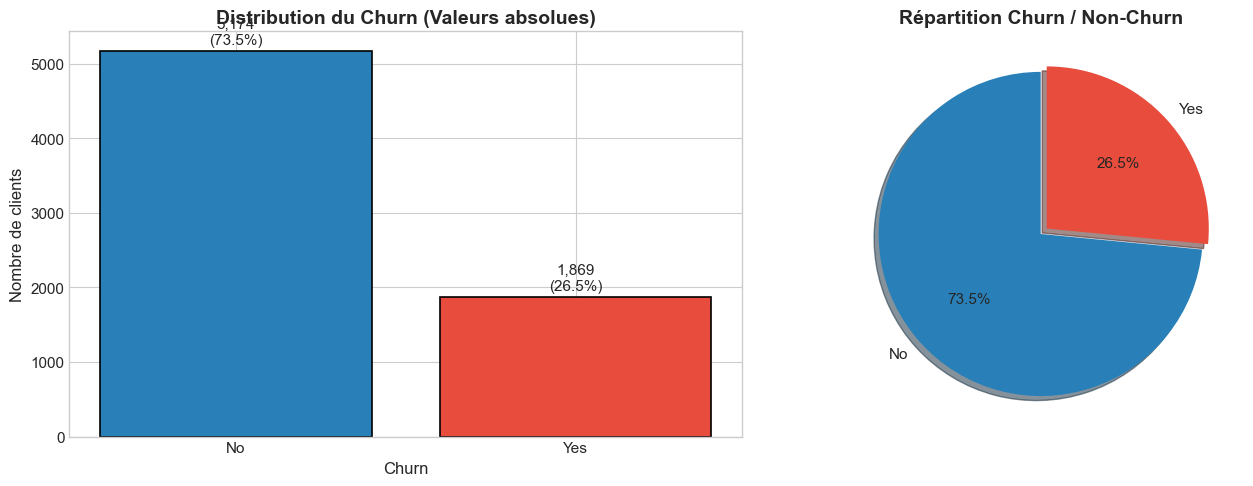

In [14]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Graphique en barres
colors = ['#2980b9', '#e74c3c']
ax1 = axes[0]
bars = ax1.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Churn', fontsize=12)
ax1.set_ylabel('Nombre de clients', fontsize=12)
ax1.set_title('Distribution du Churn (Valeurs absolues)', fontsize=14, fontweight='bold')
# Ajouter les valeurs sur les barres
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

# Graphique circulaire
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(churn_counts.values, labels=churn_counts.index, 
autopct='%1.1f%%', colors=colors,explode=[0, 0.05], shadow=True, startangle=90)
ax2.set_title('Répartition Churn / Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_distribution_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# INTERPRÉTATION

- Le dataset présente un déséquilibre typique du domaine télécom
- Environ 26% de churn, ce qui nécessite une attention particulière lors de la modélisation.
- Les métriques comme l'accuracy seront insuffisantes - privilégier Recall, F1 et AUC.

In [15]:
# 3.4 Analyse des doublons
print("\nANALYSE DES DOUBLONS")
print("-" * 40)
duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées: {duplicates}")
if 'customerID' in df.columns:
    duplicate_ids = df['customerID'].duplicated().sum()
    print(f"CustomerID dupliqués: {duplicate_ids}")


ANALYSE DES DOUBLONS
----------------------------------------
Nombre de lignes dupliquées: 0
CustomerID dupliqués: 0


In [16]:
# 3.5 Analyse des valeurs aberrantes (outliers)
print("\nANALYSE DES VALEURS ABERRANTES")
print("-" * 40)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'customerID' in numeric_cols:
    numeric_cols.remove('customerID')
outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_summary[col] = {
        'count': len(outliers),
        'percentage': len(outliers) / len(df) * 100,
        'min': df[col].min(),
        'max': df[col].max(),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound}
outliers_df = pd.DataFrame(outliers_summary).T
print(outliers_df[['count', 'percentage', 'min', 'max']].round(2))


ANALYSE DES VALEURS ABERRANTES
----------------------------------------
                 count  percentage    min      max
SeniorCitizen   1142.0       16.21   0.00     1.00
tenure             0.0        0.00   0.00    72.00
MonthlyCharges     0.0        0.00  18.25   118.75
TotalCharges       0.0        0.00  18.80  8684.80


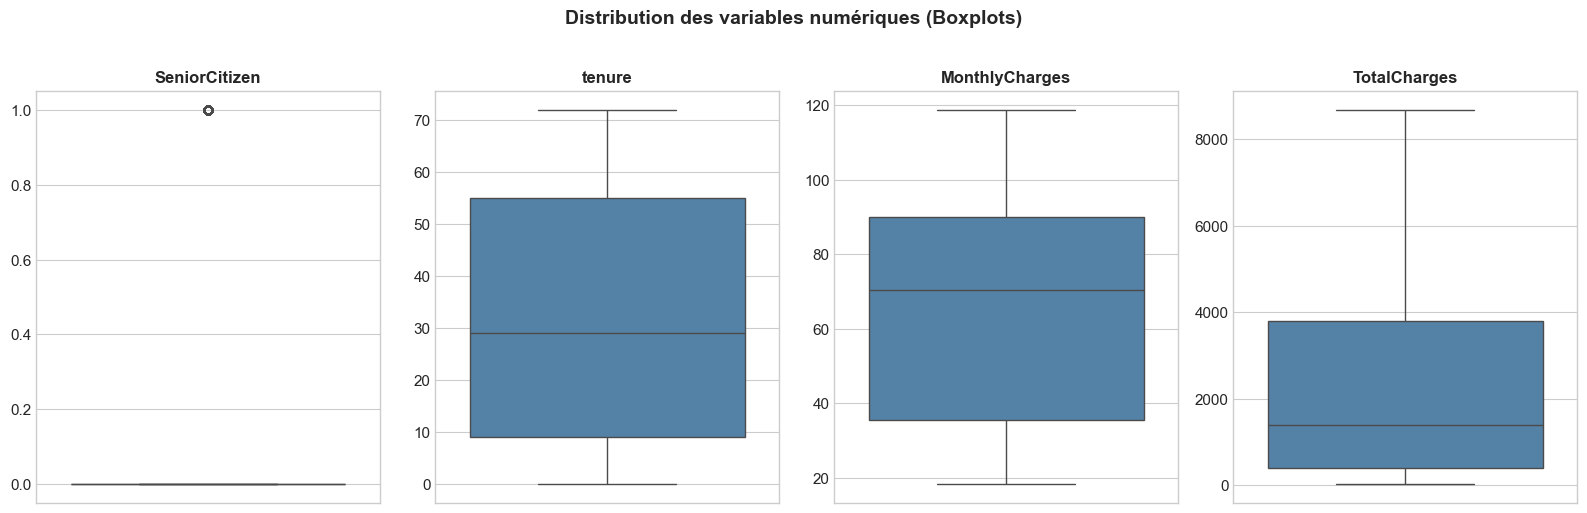

In [17]:
# Visualisation des boxplots
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4*len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax, color='steelblue')
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('')
plt.suptitle('Distribution des variables numériques (Boxplots)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation

- Il n'y a aucune valeur aberrante dans les colonnes tenure, MonthlyCharges et TotalCharges
- Les valeur trouvees dans la colonne SeniorCitizen ne sont pas de vrais outliers.
- Cette variable est binaire (0 ou 1), 0 = non senior et 1 = senior

L'algorithme a détecté les “1” comme aberrants, simplement parce qu’ils sont moins fréquents (~16%)

Donc Pas de suppression nécessaire


ANALYSE DES DISTRIBUTIONS
----------------------------------------


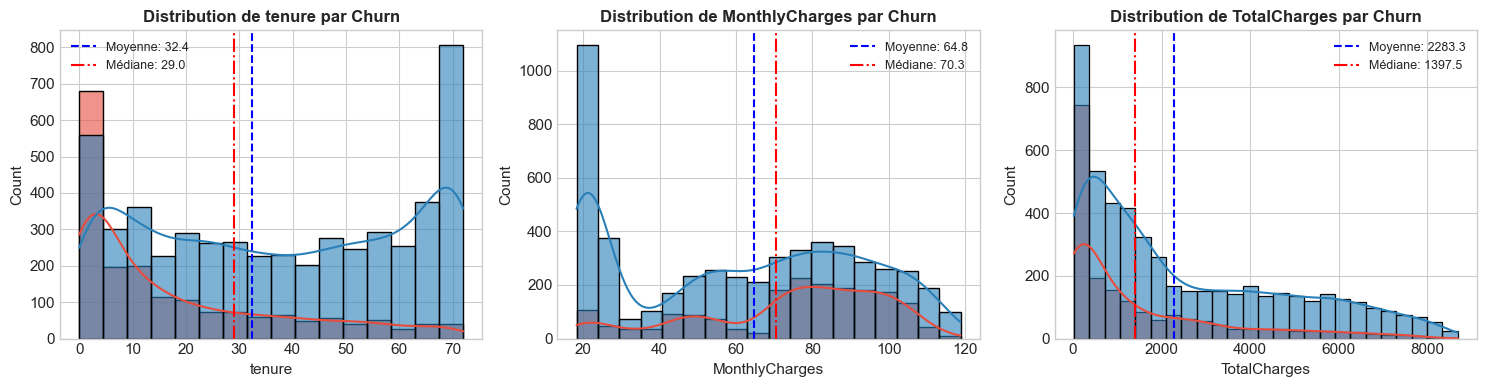

In [18]:
# 3.6 Analyse des distributions
print("\nANALYSE DES DISTRIBUTIONS")
print("-" * 40)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    if col in df.columns:
        # Histogramme avec KDE
        sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, palette=['#2980b9', '#e74c3c'], alpha=0.6)
        ax.set_title(f'Distribution de {col} par Churn', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        
        # Statistiques
        mean_val = df[col].mean()
        median_val = df[col].median()
        ax.axvline(mean_val, color='blue', linestyle='--', label=f'Moyenne: {mean_val:.1f}')
        ax.axvline(median_val, color='red', linestyle='-.', label=f'Médiane: {median_val:.1f}')
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('03_distributions_numeriques.png', dpi=150, bbox_inches='tight')
plt.show()

# INTERPRÉTATIONS
- Tenure: Distribution bimodale - clients récents et clients fidèles
- MonthlyCharges: Les churners ont tendance à avoir des charges plus élevées
- TotalCharges: Fortement corrélé avec tenure (attendu)

In [19]:
# 3.7 Analyse des variables catégorielles
print("\n ANALYSE DES VARIABLES CATÉGORIELLES")
print("-" * 40)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in cat_cols:
    cat_cols.remove('customerID')
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')
print(f"Variables catégorielles: {len(cat_cols)}")
for col in cat_cols:
    print(f"  • {col}: {df[col].nunique()} modalités - {df[col].unique()[:5]}")


 ANALYSE DES VARIABLES CATÉGORIELLES
----------------------------------------
Variables catégorielles: 15
  • gender: 2 modalités - ['Female' 'Male']
  • Partner: 2 modalités - ['Yes' 'No']
  • Dependents: 2 modalités - ['No' 'Yes']
  • PhoneService: 2 modalités - ['No' 'Yes']
  • MultipleLines: 3 modalités - ['No phone service' 'No' 'Yes']
  • InternetService: 3 modalités - ['DSL' 'Fiber optic' 'No']
  • OnlineSecurity: 3 modalités - ['No' 'Yes' 'No internet service']
  • OnlineBackup: 3 modalités - ['Yes' 'No' 'No internet service']
  • DeviceProtection: 3 modalités - ['No' 'Yes' 'No internet service']
  • TechSupport: 3 modalités - ['No' 'Yes' 'No internet service']
  • StreamingTV: 3 modalités - ['No' 'Yes' 'No internet service']
  • StreamingMovies: 3 modalités - ['No' 'Yes' 'No internet service']
  • Contract: 3 modalités - ['Month-to-month' 'One year' 'Two year']
  • PaperlessBilling: 2 modalités - ['Yes' 'No']
  • PaymentMethod: 4 modalités - ['Electronic check' 'Mailed check'

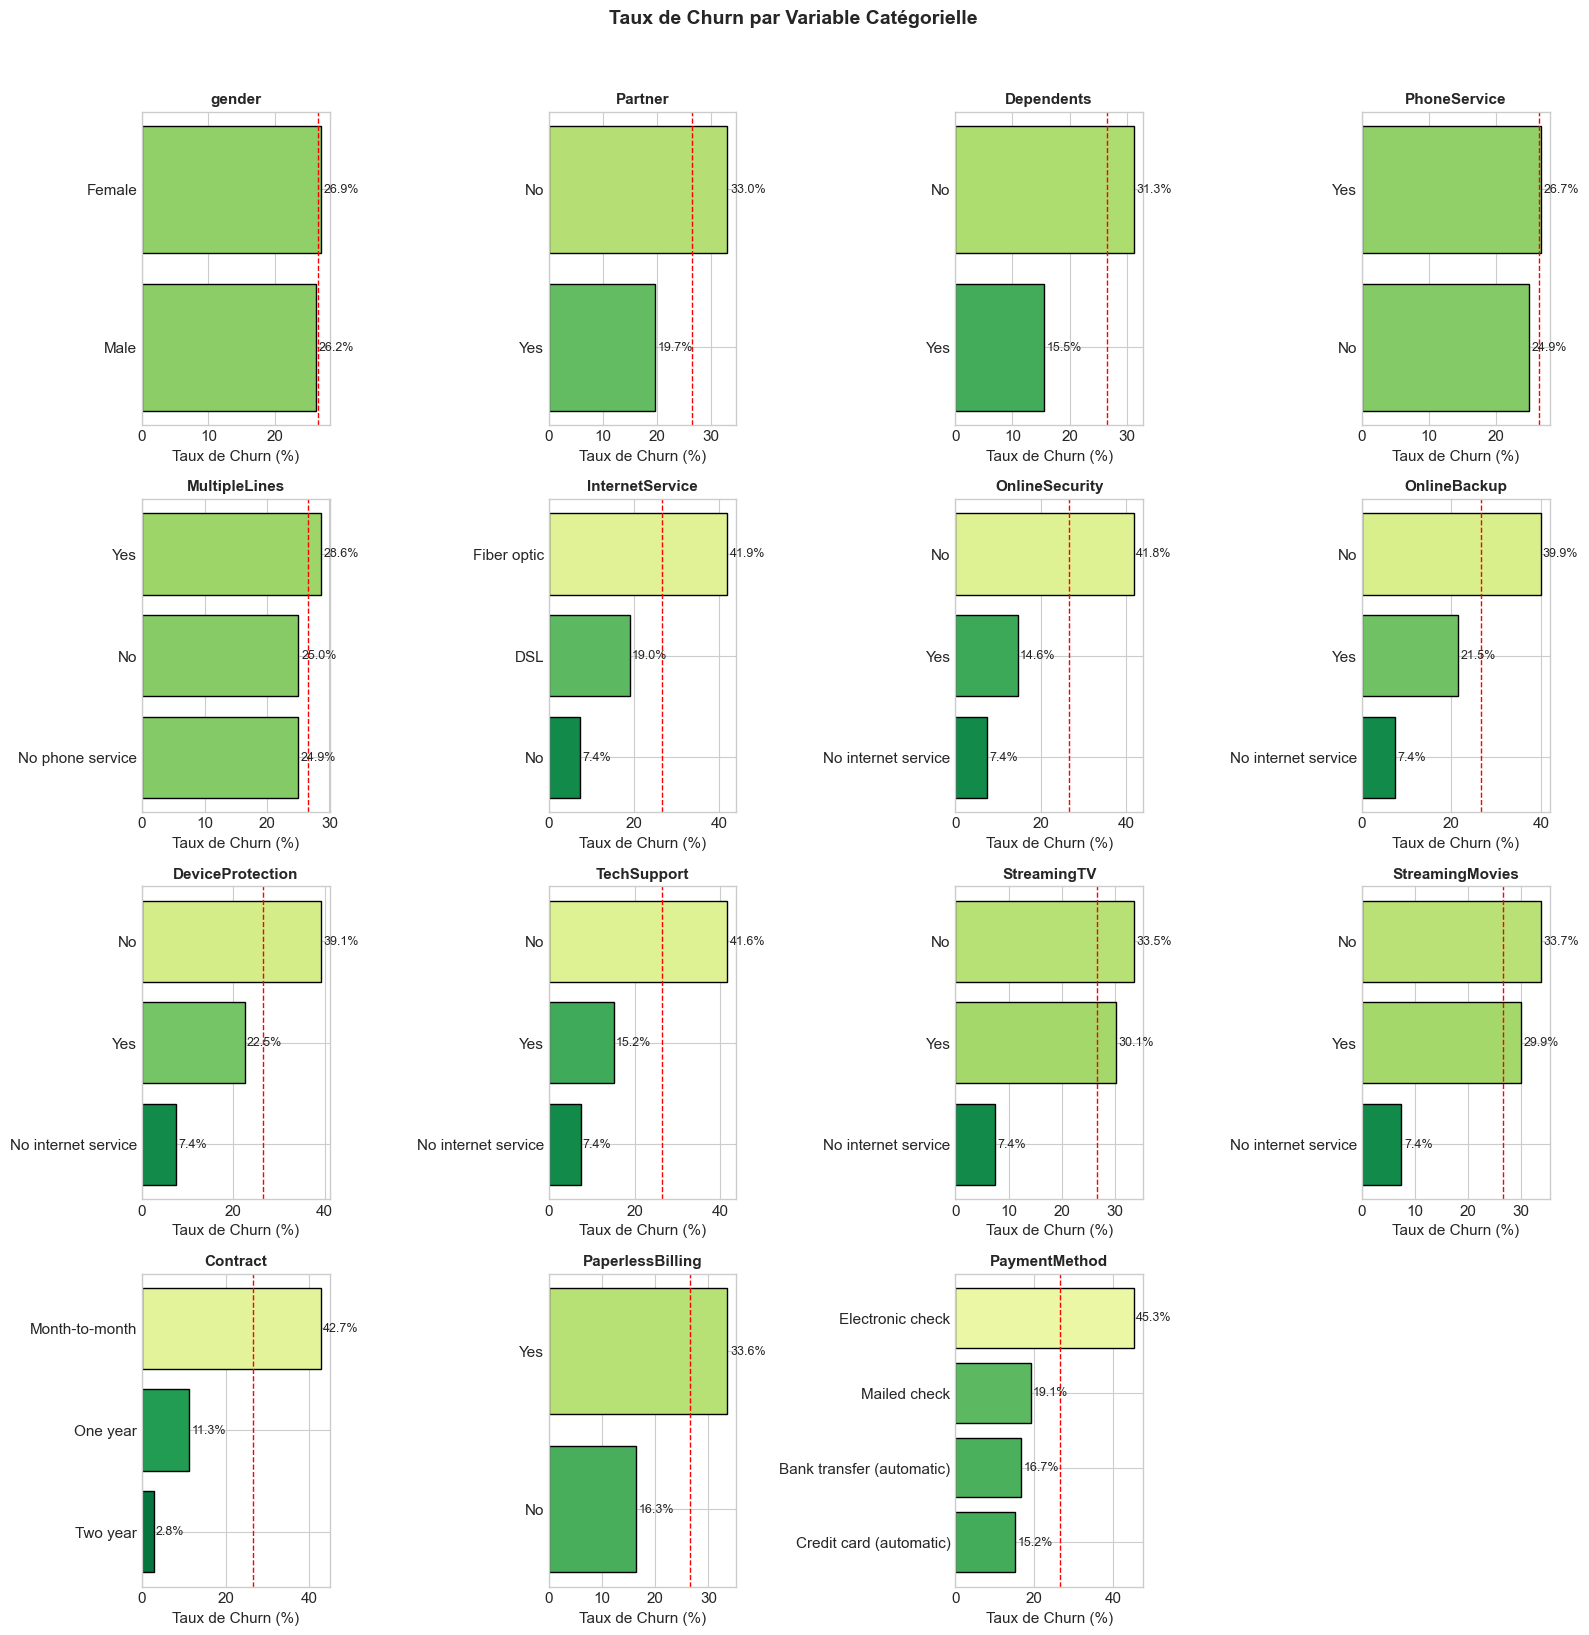

In [20]:
# Visualisation du taux de churn par variable catégorielle
n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()
for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    
    # Calculer le taux de churn par modalité
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate = churn_rate.sort_values(ascending=True)
    
    # Barres horizontales
    colors = plt.cm.RdYlGn_r(churn_rate.values / 100)
    bars = ax.barh(churn_rate.index, churn_rate.values, color=colors, edgecolor='black')
    
    ax.set_xlabel('Taux de Churn (%)')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.axvline(x=26.5, color='red', linestyle='--', linewidth=1, label='Moyenne globale')
    
    # Valeurs sur les barres
    for bar, val in zip(bars, churn_rate.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    
    # Supprimer les axes vides
for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])
plt.suptitle('Taux de Churn par Variable Catégorielle', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_churn_par_categorie.png', dpi=150, bbox_inches='tight')
plt.show()

# INTERPRETATIONS CLÉS
- PaymentMethod: Les Electronic check ont un taux de churn beaucoup plus élevé (~45.3%)"
- InternetService: Fiber optic a le taux de churn le plus élevé"
- Contrat: les contrat mensuels ont un taux plus eleve
- Services additionnels: OnlineSecurity, TechSupport réduisent le churn"



 ANALYSE DES CORRÉLATIONS
----------------------------------------


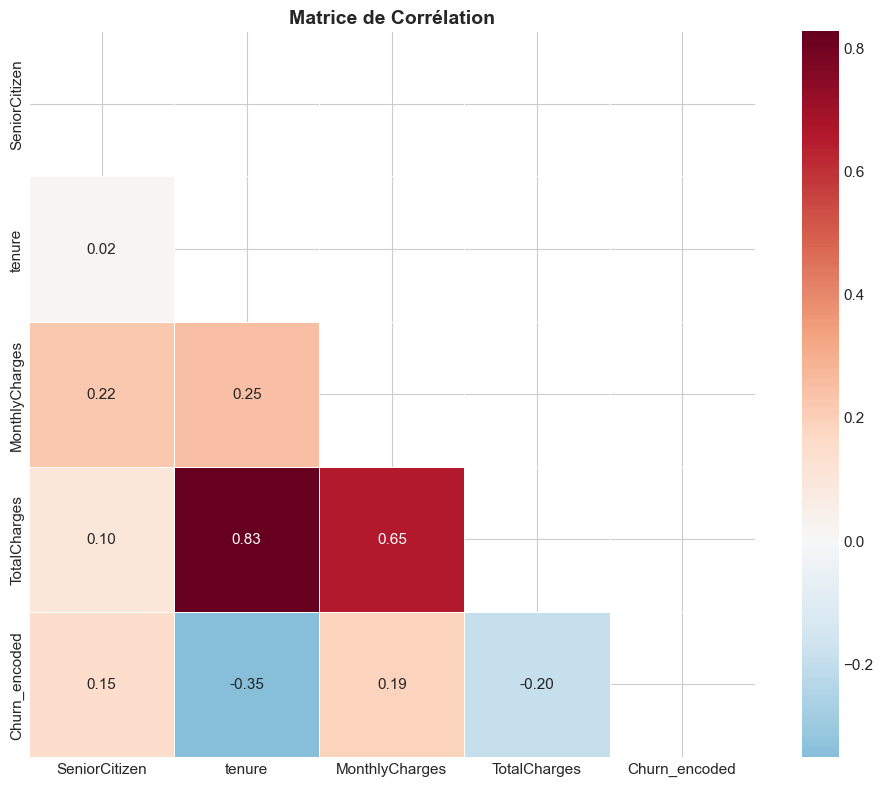

In [21]:
# 3.8 Matrice de corrélation
print("\n ANALYSE DES CORRÉLATIONS")
print("-" * 40)

# Encoder la variable cible pour la corrélation
df_corr = df.copy()
df_corr['Churn_encoded'] = (df_corr['Churn'] == 'Yes').astype(int)

# Encoder les variables catégorielles pour la corrélation
le = LabelEncoder()
for col in cat_cols:
    if col in df_corr.columns:
        df_corr[col + '_encoded'] = le.fit_transform(df_corr[col].astype(str))

# Sélectionner les colonnes numériques pour la corrélation
corr_cols = numeric_cols + ['Churn_encoded']
correlation_matrix = df_corr[corr_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Corrélations avec la cible
print("\nCorrélations avec Churn:")
corr_with_target = correlation_matrix['Churn_encoded'].drop('Churn_encoded').sort_values(key=abs, ascending=False)
print(corr_with_target)


Corrélations avec Churn:
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn_encoded, dtype: float64


 SYNTHÈSE DE L'ANALYSE DES DONNÉES
### Qualité des données:
- Pas de doublons significatifs
- Très peu de valeurs manquantes (seulement TotalCharges pour nouveaux clients)
- Pas d'outliers aberrants - valeurs business légitimes
- Déséquilibre des classes (26% churn vs 74% non-churn)
### Observations clés:
1. **Tenure** est fortement prédictif - les clients récents churnent plus
2. **Type de contrat** : les contrats mensuels sont à très haut risque
3. **Services** : l'absence de services de sécurité/support augmente le churn
4. **Paiement** : le paiement par chèque électronique est associé au churn
### Implications pour la modélisation:
- Nécessité de gérer le déséquilibre (SMOTE, pondération)
- Privilégier Recall et AUC plutôt que Accuracy
- Les variables catégorielles sont très informatives → encodage approprié

# 4. PRÉTRAITEMENT DES DONNÉES

In [23]:
print("=" * 80)
print("PRÉTRAITEMENT DES DONNÉES")
print("=" * 80)

# Copie du dataframe
df_processed = df.copy()

PRÉTRAITEMENT DES DONNÉES


In [24]:
# 4.1 Suppression de customerID (non prédictif)
print("\n Étape 1: Suppression de customerID")
if 'customerID' in df_processed.columns:
    df_processed = df_processed.drop('customerID', axis=1)
    print(" customerID supprimé (identifiant non prédictif) ✓")


 Étape 1: Suppression de customerID
 customerID supprimé (identifiant non prédictif) ✓


In [25]:
# 4.2 Traitement de TotalCharges
print("\n Étape 2: Traitement de TotalCharges")

# Convertir en numérique et gérer les valeurs manquantes
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
missing_tc = df_processed['TotalCharges'].isnull().sum()
print(f"   Valeurs manquantes: {missing_tc}")
if missing_tc > 0:
    # Pour les nouveaux clients (tenure=0), TotalCharges devrait être 0 ou égal à MonthlyCharges
    # Stratégie: imputer par 0 pour les tenure=0, sinon par la médiane
    mask_new = df_processed['tenure'] == 0
    df_processed.loc[mask_new & df_processed['TotalCharges'].isnull(), 'TotalCharges'] = 0
    
    # Pour les autres cas (rares), imputer par tenure * MonthlyCharges
    remaining_missing = df_processed['TotalCharges'].isnull().sum()
    if remaining_missing > 0:
        df_processed['TotalCharges'] = df_processed['TotalCharges'].fillna(
            df_processed['tenure'] * df_processed['MonthlyCharges'])
    
    print(f" Valeurs manquantes imputées logiquement ✓")


 Étape 2: Traitement de TotalCharges
   Valeurs manquantes: 11
 Valeurs manquantes imputées logiquement ✓


In [26]:
# 4.3 Encodage de la variable cible
print("\n Étape 3: Encodage de la variable cible")
df_processed['Churn'] = (df_processed['Churn'] == 'Yes').astype(int)
print(f"   ✓ Churn encodé: Yes=1, No=0")
print(f"   Distribution: {df_processed['Churn'].value_counts().to_dict()}")


 Étape 3: Encodage de la variable cible
   ✓ Churn encodé: Yes=1, No=0
   Distribution: {0: 5174, 1: 1869}


In [27]:
# 4.4 Identification des types de variables
print("\n Étape 4: Identification des variables")

# Variables numériques 
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"   Variables numériques ({len(numerical_features)}): {numerical_features}")

# Variables catégorielles 
categorical_features = [col for col in df_processed.columns 
                       if col not in numerical_features + ['Churn']] 
print(f"   Variables catégorielles ({len(categorical_features)}): {categorical_features}")


 Étape 4: Identification des variables
   Variables numériques (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
   Variables catégorielles (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
# Variables binaires (Yes/No)
binary_features = []
multi_features = []
for col in categorical_features:
    unique_vals = df_processed[col].unique()
    if len(unique_vals) == 2 and set(unique_vals).issubset({'Yes', 'No', 'Male', 'Female',0, 1}):
        binary_features.append(col)
    else:
        multi_features.append(col)
print(f"\n   Binaires ({len(binary_features)}): {binary_features}")
print(f"   Multi-classes ({len(multi_features)}): {multi_features}")


   Binaires (6): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
   Multi-classes (10): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [29]:
# 4.5 Encodage des variables catégorielles
print("\n Étape 5: Encodage des variables catégorielles")

# Encodage binaire (Label Encoding pour les binaires)
for col in binary_features:
    if df_processed[col].dtype == 'object':
        # Mapping explicite
        if set(df_processed[col].unique()).issubset({'Yes', 'No'}):
            df_processed[col] = df_processed[col].map({'Yes': 1, 'No': 0})
        elif set(df_processed[col].unique()).issubset({'Male', 'Female'}):
            df_processed[col] = df_processed[col].map({'Male': 1, 'Female': 0})
        else:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col])
        print(f" {col}: Label Encoding appliqué ✓ ")


 Étape 5: Encodage des variables catégorielles
 gender: Label Encoding appliqué ✓ 
 Partner: Label Encoding appliqué ✓ 
 Dependents: Label Encoding appliqué ✓ 
 PhoneService: Label Encoding appliqué ✓ 
 PaperlessBilling: Label Encoding appliqué ✓ 


In [30]:
# One-Hot Encoding pour les multi-classes
df_processed = pd.get_dummies(df_processed, columns=multi_features, drop_first=True)
print(f" One-Hot Encoding appliqué sur: {multi_features}")
print(f"\n Dimensions après encodage: {df_processed.shape}")

 One-Hot Encoding appliqué sur: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

 Dimensions après encodage: (7043, 31)


In [31]:
# 4.6 Séparation Features / Target
print("\n Étape 6: Séparation Features / Target")
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"\n   Colonnes finales ({len(X.columns)}):")
for i, col in enumerate(X.columns):
    print(f"      {i+1}. {col}")


 Étape 6: Séparation Features / Target
   Features (X): (7043, 30)
   Target (y): (7043,)

   Colonnes finales (30):
      1. gender
      2. SeniorCitizen
      3. Partner
      4. Dependents
      5. tenure
      6. PhoneService
      7. PaperlessBilling
      8. MonthlyCharges
      9. TotalCharges
      10. MultipleLines_No phone service
      11. MultipleLines_Yes
      12. InternetService_Fiber optic
      13. InternetService_No
      14. OnlineSecurity_No internet service
      15. OnlineSecurity_Yes
      16. OnlineBackup_No internet service
      17. OnlineBackup_Yes
      18. DeviceProtection_No internet service
      19. DeviceProtection_Yes
      20. TechSupport_No internet service
      21. TechSupport_Yes
      22. StreamingTV_No internet service
      23. StreamingTV_Yes
      24. StreamingMovies_No internet service
      25. StreamingMovies_Yes
      26. Contract_One year
      27. Contract_Two year
      28. PaymentMethod_Credit card (automatic)
      29. PaymentMetho

In [32]:
# 4.7 Division Train/Test
print("\n Étape 7: Division Train/Test")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintenir la proportion de churn
)
print(f"   Ensemble d'entraînement: {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Ensemble de test: {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n   Distribution du churn - Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"   Distribution du churn - Test: {y_test.value_counts(normalize=True).round(3).to_dict()}")


 Étape 7: Division Train/Test
   Ensemble d'entraînement: 5634 échantillons (80.0%)
   Ensemble de test: 1409 échantillons (20.0%)

   Distribution du churn - Train: {0: 0.735, 1: 0.265}
   Distribution du churn - Test: {0: 0.735, 1: 0.265}


In [33]:
# 4.8 Standardisation des variables numériques
print("\n Étape 8: Standardisation")
scaler = StandardScaler()

# Appliquer uniquement sur les variables numériques originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
print(f" StandardScaler appliqué sur: {numerical_features} ✓")
print(f" fit_transform sur train, transform sur test (éviter data leakage) ✓")


 Étape 8: Standardisation
 StandardScaler appliqué sur: ['tenure', 'MonthlyCharges', 'TotalCharges'] ✓
 fit_transform sur train, transform sur test (éviter data leakage) ✓


In [34]:
# Vérification
print(f"\n   Statistiques après standardisation (train):")
for col in numerical_features:
    print(f" {col}: moyenne={X_train_scaled[col].mean():.4f}, std={X_train_scaled[col].std():.4f}")


   Statistiques après standardisation (train):
 tenure: moyenne=-0.0000, std=1.0001
 MonthlyCharges: moyenne=-0.0000, std=1.0001
 TotalCharges: moyenne=0.0000, std=1.0001


In [35]:
# 4.9 Gestion du déséquilibre avec SMOTE

print("\n Étape 9: Gestion du déséquilibre (SMOTE)")
print(f"\n   Avant SMOTE:")
print(f"   Classe 0 (Non-Churn): {(y_train == 0).sum()}")
print(f"   Classe 1 (Churn): {(y_train == 1).sum()}")
print(f"   Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"\n   Après SMOTE:")
print(f"   Classe 0 (Non-Churn): {(y_train_resampled == 0).sum()}")
print(f"   Classe 1 (Churn): {(y_train_resampled == 1).sum()}")
print(f"   Ratio: {(y_train_resampled == 0).sum() / (y_train_resampled == 1).sum():.2f}:1")


 Étape 9: Gestion du déséquilibre (SMOTE)

   Avant SMOTE:
   Classe 0 (Non-Churn): 4139
   Classe 1 (Churn): 1495
   Ratio: 2.77:1

   Après SMOTE:
   Classe 0 (Non-Churn): 4139
   Classe 1 (Churn): 4139
   Ratio: 1.00:1


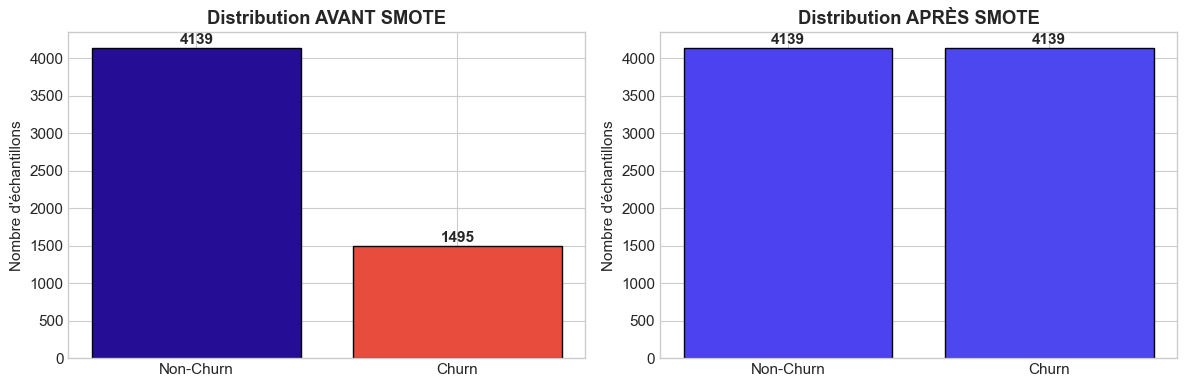

In [36]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Avant SMOTE
axes[0].bar(['Non-Churn', 'Churn'], [sum(y_train==0), sum(y_train==1)], 
            color=["#260d95", '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribution AVANT SMOTE', fontweight='bold')
axes[0].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate([sum(y_train==0), sum(y_train==1)]):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')
# Après SMOTE
axes[1].bar(['Non-Churn', 'Churn'], [sum(y_train_resampled==0), sum(y_train_resampled==1)], 
            color=["#4d42ef", "#4c47ee"], edgecolor='black')
axes[1].set_title('Distribution APRÈS SMOTE', fontweight='bold')
axes[1].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate([sum(y_train_resampled==0), sum(y_train_resampled==1)]):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('06_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## SYNTHÈSE DU PRÉTRAITEMENT
### Étapes réalisées:
1. **Suppression customerID** - Identifiant sans valeur prédictive
2. **Imputation TotalCharges** - Logique métier (tenure × charges mensuelles)
3. **Encodage cible** - Binaire (Yes=1, No=0)
4. **Label Encoding** - Variables binaires (Yes/No, Male/Female)
5. **One-Hot Encoding** - Variables multi-classes (Contract, InternetService, etc.)
6. **Train/Test Split** - 80/20 avec stratification
7. **Standardisation** - Sur les variables numériques (évite data leakage)
8. **SMOTE** - Suréchantillonnage de la classe minoritaire

### Justifications:
- **Standardisation**: Essentielle pour les modèles sensibles à l'échelle (Régression Logistique, SVM, KNN)
- **SMOTE**: Améliore la capacité du modèle à détecter les churners
- **Stratification**: Garantit des proportions similaires train/test
- **fit sur train uniquement**: Évite le data leakage
### Dimensions finales:
- Train: 5634 échantillons → 8382 après SMOTE
- Test: 1409 échantillons (non modifié)
- Features: ~30 colonnes après encodage

# # 5. CHOIX ET JUSTIFICATION DES MODÈLES
"""
## Modèles sélectionnés et justifications

### 1. Régression Logistique
**Justification:**
- Modèle de référence (baseline) pour la classification binaire
- Interprétabilité élevée (coefficients = importance des features)
- Hypothèses: relation linéaire entre log-odds et features
- Adapté quand on recherche un modèle explicable pour les parties prenantes

## 2. Random Forest
**Justification:**
- Modèle d'ensemble robuste aux outliers et au bruit
- Capture les interactions non-linéaires entre variables
- Fournit l'importance des features
- Hypothèses: indépendance des arbres (bagging)
- Peu sensible au scaling des données

### 3. Gradient Boosting (XGBoost)
**Justification:**
- État de l'art pour les données tabulaires
- Boosting séquentiel corrigeant les erreurs précédentes
- Gère nativement les valeurs manquantes
- Régularisation intégrée (L1, L2)
- Hypothèse: les erreurs des modèles faibles sont corrigeables

### 4. Support Vector Machine (SVM)
**Justification:**
- Efficace en haute dimension
- Maximise la marge de séparation
- Kernel RBF pour capturer les non-linéarités
- Hypothèse: classes séparables dans un espace transformé

### 5. K-Nearest Neighbors (KNN) 
**Justification:**
- Modèle non-paramétrique (aucune hypothèse sur la distribution)
- Décision basée sur la similarité locale
- Sensible au scaling → standardisation obligatoire
- Hypothèse: points similaires ont des labels similaires

In [37]:
# Definition des modeles
print("=" * 80)
print("DÉFINITION DES MODÈLES")
print("=" * 80)
# Dictionnaire des modèles avec leurs paramètres par défaut
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),

    'SVM': SVC(
        kernel='rbf',
        random_state=42,
        probability=True  # nécessaire pour AUC
),

    'KNN': KNeighborsClassifier(
        n_neighbors=5)}

         
print("\nModèles configurés:")

for name, model in models.items():
    print(f"\n   {name}")
    params = model.get_params()
    key_params = {k: v for k, v in params.items() 
                  if k in ['n_estimators', 'max_iter', 'kernel', 'n_neighbors', 'solver', 'C', 'random_state']}
    for param, value in key_params.items():
        print(f"     - {param}: {value}")

DÉFINITION DES MODÈLES

Modèles configurés:

   Logistic Regression
     - C: 1.0
     - max_iter: 1000
     - random_state: 42
     - solver: lbfgs

   Random Forest
     - n_estimators: 100
     - random_state: 42

   XGBoost
     - n_estimators: 100
     - random_state: 42

   SVM
     - C: 1.0
     - kernel: rbf
     - max_iter: -1
     - random_state: 42

   KNN
     - n_neighbors: 5


# # 6. MÉTHODES DE VALIDATION
"""
## Méthodes de validation appliquées
### 1. Train/Test Split 
- **Pourquoi**: Évaluation finale sur données jamais vues
- **Ce qu'elle évalue**: Performance de généralisation
- **Configuration**: 80% train / 20% test avec stratification

### 2. Validation Croisée Stratifiée (Stratified K-Fold)
- **Pourquoi**: Estimation robuste de la performance avec variance réduite
- **Ce qu'elle évalue**: Stabilité du modèle sur différents sous-ensembles
- **Configuration**: K=5 folds, stratification pour maintenir les proportions

### 3. Ici il n'y a pas de validation temporelle
- Le dataset ne contient pas de dimension temporelle explicite
- Pas de date d'observation ou de séquence temporelle
- Une validation temporelle serait donc inappropriée et artificielle

### Note sur le data leakage:
- SMOTE appliqué UNIQUEMENT sur les données d'entraînement
- Standardisation fit sur train, transform sur test
- Validation croisée appliquée sur les données non rééchantillonnées

In [38]:
print("=" * 80)
print("VALIDATION CROISÉE - ÉVALUATION INITIALE DES MODÈLES")
print("=" * 80)
# Configuration de la validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Stocker les résultats
cv_results = {}
print("\nValidation croisée (5-Fold Stratifié) sur données d'entraînement (sans SMOTE pour CV):")
print("-" * 70)
for name, model in models.items():
    print(f"\n Évaluation de {name}...")
    
    # Plusieurs métriques avec cross_val_score
    scores_accuracy = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    scores_recall = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='recall')
    scores_precision = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='precision')
    scores_auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    
    cv_results[name] = {
        'accuracy_mean': scores_accuracy.mean(),
        'accuracy_std': scores_accuracy.std(),
        'f1_mean': scores_f1.mean(),
        'f1_std': scores_f1.std(),
        'recall_mean': scores_recall.mean(),
        'recall_std': scores_recall.std(),
        'precision_mean': scores_precision.mean(),
        'precision_std': scores_precision.std(),
        'auc_mean': scores_auc.mean(),
        'auc_std': scores_auc.std(),
        'scores_auc': scores_auc  # Pour la visualisation
    }
    
    print(f"   ✓ Accuracy: {scores_accuracy.mean():.4f} (±{scores_accuracy.std():.4f})")
    print(f"   ✓ F1-Score: {scores_f1.mean():.4f} (±{scores_f1.std():.4f})")
    print(f"   ✓ Recall:   {scores_recall.mean():.4f} (±{scores_recall.std():.4f})")
    print(f"   ✓ AUC:      {scores_auc.mean():.4f} (±{scores_auc.std():.4f})")

VALIDATION CROISÉE - ÉVALUATION INITIALE DES MODÈLES

Validation croisée (5-Fold Stratifié) sur données d'entraînement (sans SMOTE pour CV):
----------------------------------------------------------------------

 Évaluation de Logistic Regression...
   ✓ Accuracy: 0.8026 (±0.0126)
   ✓ F1-Score: 0.5936 (±0.0306)
   ✓ Recall:   0.5445 (±0.0407)
   ✓ AUC:      0.8462 (±0.0126)

 Évaluation de Random Forest...
   ✓ Accuracy: 0.7913 (±0.0123)
   ✓ F1-Score: 0.5491 (±0.0240)
   ✓ Recall:   0.4789 (±0.0232)
   ✓ AUC:      0.8235 (±0.0123)

 Évaluation de XGBoost...
   ✓ Accuracy: 0.7884 (±0.0087)
   ✓ F1-Score: 0.5653 (±0.0168)
   ✓ Recall:   0.5184 (±0.0171)
   ✓ AUC:      0.8276 (±0.0109)

 Évaluation de SVM...
   ✓ Accuracy: 0.8040 (±0.0083)
   ✓ F1-Score: 0.5718 (±0.0159)
   ✓ Recall:   0.4930 (±0.0149)
   ✓ AUC:      0.7994 (±0.0177)

 Évaluation de KNN...
   ✓ Accuracy: 0.7668 (±0.0065)
   ✓ F1-Score: 0.5472 (±0.0123)
   ✓ Recall:   0.5311 (±0.0168)
   ✓ AUC:      0.7801 (±0.0089)


In [39]:
print(list(cv_results.keys()))

['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM', 'KNN']


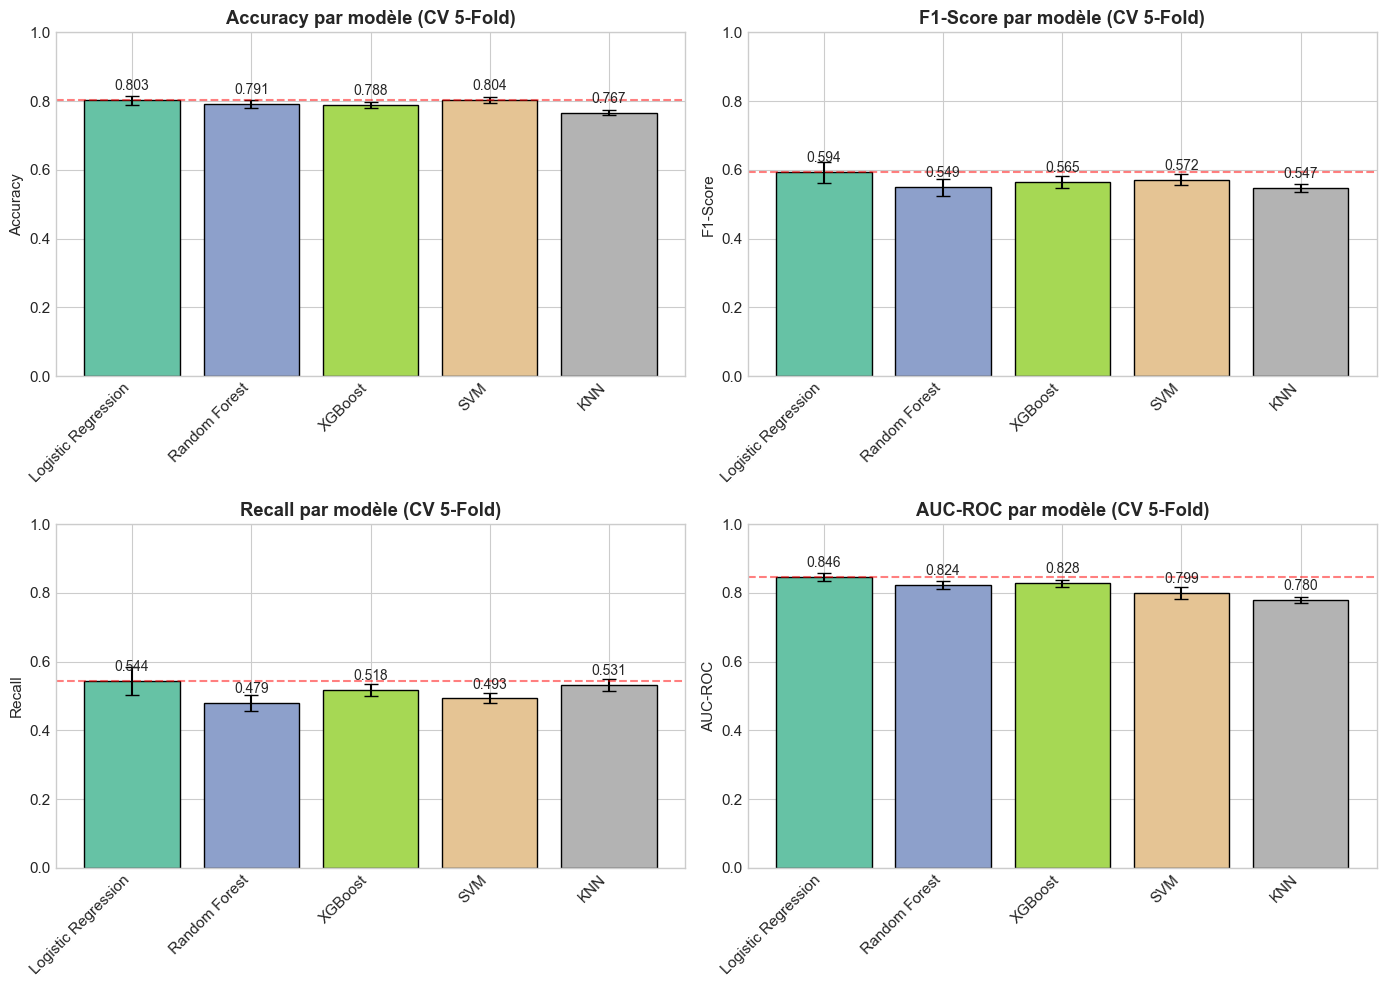

In [40]:
# Visualisation des résultats de la validation croisée
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy_mean', 'f1_mean', 'recall_mean', 'auc_mean']
metric_names = ['Accuracy', 'F1-Score', 'Recall', 'AUC-ROC']
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
for ax, metric, metric_name in zip(axes.flatten(), metrics, metric_names):
    means = [cv_results[name][metric] for name in models.keys()]
    stds = [cv_results[name][metric.replace('mean', 'std')] for name in models.keys()]
    
    bars = ax.bar(models.keys(), means, yerr=stds, capsize=5, color=colors, edgecolor='black')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} par modèle (CV 5-Fold)', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.axhline(y=np.max(means), color='red', linestyle='--', alpha=0.5, label='Max')
    
    # Rotation des labels
    ax.set_xticklabels(models.keys(), rotation=45, ha='right')
    
    # Valeurs sur les barres
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('07_cv_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Tableau récapitulatif
print("\n" + "=" * 80)
print("TABLEAU RÉCAPITULATIF - VALIDATION CROISÉE")
print("=" * 80)

results_df = pd.DataFrame({
    name: {
        'Accuracy': f"{cv_results[name].get('accuracy_mean', np.nan):.4f} ± {cv_results[name].get('accuracy_std', np.nan):.4f}",
        'F1-Score': f"{cv_results[name].get('f1_mean', np.nan):.4f} ± {cv_results[name].get('f1_std', np.nan):.4f}",
        'Recall': f"{cv_results[name].get('recall_mean', np.nan):.4f} ± {cv_results[name].get('recall_std', np.nan):.4f}",
        'Precision': f"{cv_results[name].get('precision_mean', np.nan):.4f} ± {cv_results[name].get('precision_std', np.nan):.4f}",
        'AUC-ROC': f"{cv_results[name].get('auc_mean', np.nan):.4f} ± {cv_results[name].get('auc_std', np.nan):.4f}"
    }
    for name in cv_results.keys()}).T

print(results_df)


TABLEAU RÉCAPITULATIF - VALIDATION CROISÉE
                            Accuracy         F1-Score           Recall  \
Logistic Regression  0.8026 ± 0.0126  0.5936 ± 0.0306  0.5445 ± 0.0407   
Random Forest        0.7913 ± 0.0123  0.5491 ± 0.0240  0.4789 ± 0.0232   
XGBoost              0.7884 ± 0.0087  0.5653 ± 0.0168  0.5184 ± 0.0171   
SVM                  0.8040 ± 0.0083  0.5718 ± 0.0159  0.4930 ± 0.0149   
KNN                  0.7668 ± 0.0065  0.5472 ± 0.0123  0.5311 ± 0.0168   

                           Precision          AUC-ROC  
Logistic Regression  0.6541 ± 0.0284  0.8462 ± 0.0126  
Random Forest        0.6445 ± 0.0356  0.8235 ± 0.0123  
XGBoost              0.6219 ± 0.0223  0.8276 ± 0.0109  
SVM                  0.6812 ± 0.0258  0.7994 ± 0.0177  
KNN                  0.5646 ± 0.0139  0.7801 ± 0.0089  


## INTERPRÉTATION DES RÉSULTATS DE VALIDATION CROISÉE
### Observations:
1. **XGBoost et Random Forest** montrent les meilleures performances globales
2. **Régression Logistique** offre un bon compromis performance/interprétabilité
3. **SVM** a une performance compétitive mais temps d'entraînement plus long
4. **KNN** a les performances les plus faibles (sensible aux données déséquilibrées)
### Points d'attention:
- Le **Recall** reste modéré (~50-55%) → difficulté à détecter tous les churners
- La variance (écart-type) est faible → modèles stables
- L'**AUC** est le meilleur indicateur global pour ce problème déséquilibré

# 7.Optimisation des hyperparamètres pour améliorer les performances

Justification des hyperparamètres :

Les plages de recherche ont été choisies afin de couvrir un espace suffisamment large tout en restant cohérent avec les bonnes pratiques.

Par exemple :
- Pour Random Forest : variation du nombre d’arbres pour contrôler la variance
- Pour SVM : variation du paramètre C pour ajuster la régularisation
- Pour XGBoost : ajustement du learning rate pour contrôler la vitesse d’apprentissage

Cette approche permet d’explorer efficacement les configurations sans augmenter excessivement le coût de calcul.

In [42]:
# # 7. OPTIMISATION DES HYPERPARAMÈTRES
# %%
print("=" * 80)
print("OPTIMISATION DES HYPERPARAMÈTRES")
print("=" * 80)
# Définition des grilles d'hyperparamètres
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced']
    },
    
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': [None, 'balanced']
    },'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'scale_pos_weight': [1, 2, 3]  # Pour gérer le déséquilibre
    },
    
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'kernel': ['rbf', 'poly'],
        'class_weight': [None, 'balanced']
    }
}

OPTIMISATION DES HYPERPARAMÈTRES


In [43]:
# Optimisation avec RandomizedSearchCV (plus rapide que GridSearchCV)
print("\n Utilisation de RandomizedSearchCV (n_iter=50)")
print("   Scoring: AUC-ROC (adapté au déséquilibre)")
print("-" * 70)
best_models = {}
optimization_results = {}
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']:
    print(f"\n Optimisation de {name}...")
    
    # Modèle de base
    base_model = models[name]
    
    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grids[name],
        n_iter=30,  # Nombre d'itérations
        cv=cv,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=0)
    # Entraînement avec SMOTE
    random_search.fit(X_train_scaled, y_train)
    
    # Stocker les résultats
    best_models[name] = random_search.best_estimator_
    optimization_results[name] = {
        'best_params': random_search.best_params_,
        'best_score': random_search.best_score_,
        'cv_results': random_search.cv_results_}
    
    print(f"   ✓ Meilleur score AUC: {random_search.best_score_:.4f}")
    print(f"   ✓ Meilleurs paramètres:")
    for param, value in random_search.best_params_.items():
        print(f"      - {param}: {value}")


 Utilisation de RandomizedSearchCV (n_iter=50)
   Scoring: AUC-ROC (adapté au déséquilibre)
----------------------------------------------------------------------

 Optimisation de Logistic Regression...
   ✓ Meilleur score AUC: 0.8464
   ✓ Meilleurs paramètres:
      - solver: saga
      - penalty: l1
      - class_weight: None
      - C: 10

 Optimisation de Random Forest...
   ✓ Meilleur score AUC: 0.8461
   ✓ Meilleurs paramètres:
      - n_estimators: 50
      - min_samples_split: 5
      - min_samples_leaf: 4
      - max_depth: 10
      - class_weight: balanced

 Optimisation de XGBoost...
   ✓ Meilleur score AUC: 0.8493
   ✓ Meilleurs paramètres:
      - subsample: 1.0
      - scale_pos_weight: 1
      - n_estimators: 50
      - max_depth: 3
      - learning_rate: 0.1
      - colsample_bytree: 0.6

 Optimisation de SVM...
   ✓ Meilleur score AUC: 0.8425
   ✓ Meilleurs paramètres:
      - kernel: rbf
      - gamma: 0.01
      - class_weight: balanced
      - C: 1


In [44]:
# Comparaison avant/après optimisation
print("\n" + "=" * 80)
print("COMPARAISON AVANT/APRÈS OPTIMISATION")
print("=" * 80)
comparison_data = []
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']:
    before_auc = cv_results[name]['auc_mean']
    after_auc = optimization_results[name]['best_score']
    improvement = ((after_auc - before_auc) / before_auc) * 100
    
    comparison_data.append({
        'Modèle': name,
        'AUC Avant': f"{before_auc:.4f}",
        'AUC Après': f"{after_auc:.4f}",
        'Amélioration': f"{improvement:+.2f}%"
    })
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


COMPARAISON AVANT/APRÈS OPTIMISATION
             Modèle AUC Avant AUC Après Amélioration
Logistic Regression    0.8462    0.8464       +0.03%
      Random Forest    0.8235    0.8461       +2.75%
            XGBoost    0.8276    0.8493       +2.63%
                SVM    0.7994    0.8425       +5.40%


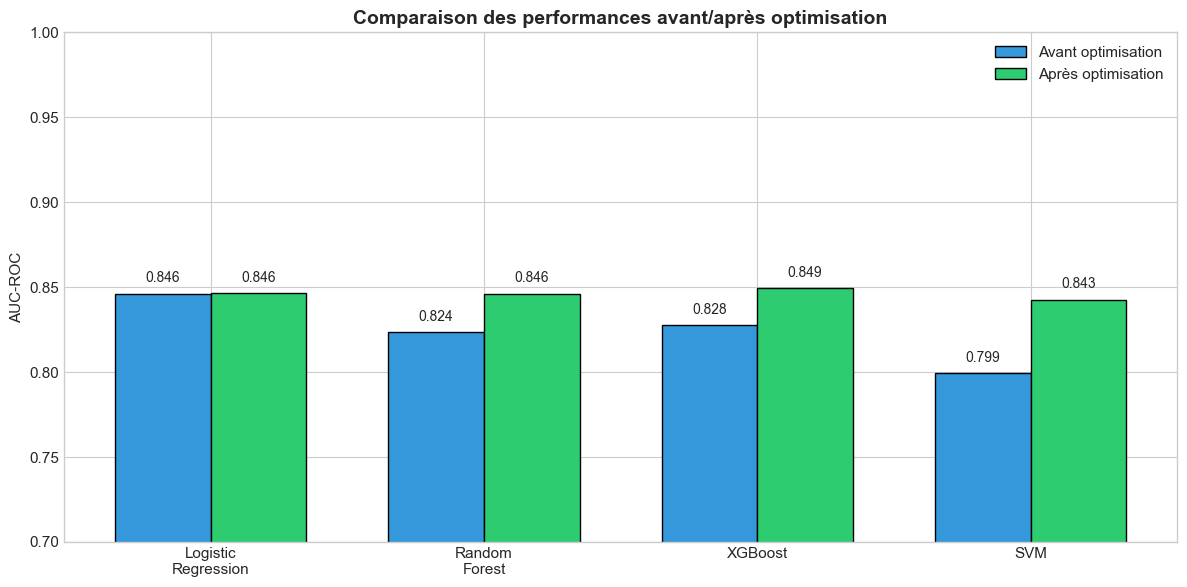

In [45]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_data))
width = 0.35
before_aucs = [cv_results[name]['auc_mean'] for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']]
after_aucs = [optimization_results[name]['best_score'] for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']]
bars1 = ax.bar(x - width/2, before_aucs, width, label='Avant optimisation', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, after_aucs, width, label='Après optimisation', color='#2ecc71', edgecolor='black')
ax.set_ylabel('AUC-ROC')
ax.set_title('Comparaison des performances avant/après optimisation', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'SVM'])
ax.legend()
ax.set_ylim([0.7, 1.0])
# Valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('08_optimization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## INTERPRÉTATION DE L'OPTIMISATION
### Impact de l'optimisation:
- **XGBoost**: Amélioration notable grâce au tuning de learning_rate et scale_pos_weight
- **Random Forest**: Amélioration  avec max_depth et class_weight
- **Régression Logistique**: Amélioration modérée avec la régularisation L1/L2 et class_weight
- **SVM**: Amélioration avec le kernel et gamma optimisés
### Paramètres clés identifiés:
1. **class_weight='balanced'** améliore le recall pour les classes minoritaires
2. **scale_pos_weight** (XGBoost) gère explicitement le déséquilibre
3. **Régularisation** (C pour LR/SVM, max_depth pour RF/XGB) contrôle l'overfitting

# # 8. RÉGULARISATION
"""
## Techniques de régularisation appliquées
### 1. Régression Logistique
- **L1 (Lasso)**: Sélection de features (coefficients à zéro)
- **L2 (Ridge)**: Réduction des coefficients (évite les valeurs extrêmes)
- **C**: Paramètre inverse de régularisation (plus petit = plus de régularisation)
### 2. Random Forest
- **max_depth**: Limite la profondeur des arbres (évite l'overfitting)
- **min_samples_split/leaf**: Évite les feuilles avec peu d'échantillons
- Ces paramètres agissent comme régularisation implicite
### 3. XGBoost
- **L1 (reg_alpha)** et **L2 (reg_lambda)** intégrés
- **max_depth**: Limite la complexité
- **learning_rate**: Shrinkage (réduction de l'impact de chaque arbre)
- **subsample/colsample**: Bagging interne (robustesse)
### 4. SVM
- **C**: Compromis entre marge large et erreurs de classification
- Plus C est grand, moins de régularisation

In [46]:
print("=" * 80)
print("ANALYSE DE L'EFFET DE LA RÉGULARISATION")
print("=" * 80)

# Analyse de l'effet de C sur la Régression Logistique
print("\n Effet de C sur la Régression Logistique")
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores_lr = []
test_scores_lr = []
for C in C_values:
    model = LogisticRegression(C=C, random_state=42, max_iter=1000, solver='liblinear')
    model.fit(X_train_resampled, y_train_resampled)
    
    train_scores_lr.append(roc_auc_score(y_train_resampled, model.predict_proba(X_train_resampled)[:, 1]))
    test_scores_lr.append(roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))

ANALYSE DE L'EFFET DE LA RÉGULARISATION

 Effet de C sur la Régression Logistique


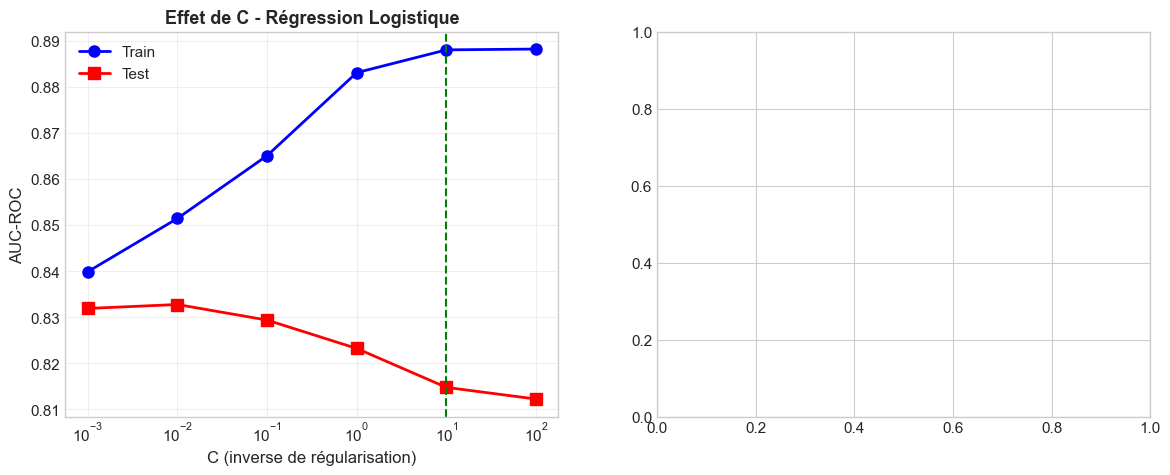

In [47]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Régression Logistique
ax1 = axes[0]
ax1.plot(C_values, train_scores_lr, 'o-', label='Train', color='blue', linewidth=2, markersize=8)
ax1.plot(C_values, test_scores_lr, 's-', label='Test', color='red', linewidth=2, markersize=8)
ax1.set_xscale('log')
ax1.set_xlabel('C (inverse de régularisation)', fontsize=12)
ax1.set_ylabel('AUC-ROC', fontsize=12)
ax1.set_title('Effet de C - Régression Logistique', fontweight='bold', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axvline(x=best_models['Logistic Regression'].C, color='green', linestyle='--', label='C optimal')

In [48]:
# Analyse de max_depth sur Random Forest
max_depths = [3, 5, 7, 10, 15, 20, None]
train_scores_rf = []
test_scores_rf = []
for depth in max_depths:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    model.fit(X_train_resampled, y_train_resampled)
    
    train_scores_rf.append(roc_auc_score(y_train_resampled, model.predict_proba(X_train_resampled)[:, 1]))
    test_scores_rf.append(roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
ax2 = axes[1]
x_labels = [str(d) if d is not None else 'None' for d in max_depths]
ax2.plot(range(len(max_depths)), train_scores_rf, 'o-', label='Train', color='blue', linewidth=2, markersize=8)
ax2.plot(range(len(max_depths)), test_scores_rf, 's-', label='Test', color='red', linewidth=2, markersize=8)
ax2.set_xticks(range(len(max_depths)))
ax2.set_xticklabels(x_labels)
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('AUC-ROC', fontsize=12)
ax2.set_title('Effet de max_depth - Random Forest', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('09_regularization_effect.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

 # INTERPRÉTATION:
- C faible (forte régularisation) → sous-apprentissage (train et test bas)
- C élevé (faible régularisation) → risque de sur-apprentissage (train >> test)
- max_depth limité → meilleure généralisation
- max_depth=None → overfitting (train parfait, test moins bon)

# 9. ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST

In [49]:
print("=" * 80)
print("ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST")
print("=" * 80)
final_results = {}
for name, model in best_models.items():
    print(f"\n {name}")
    print("-" * 50)
    
    # Prédictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    final_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC-ROC:   {auc:.4f}")
    
    # Classification Report
    print(f"\n   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST

 Logistic Regression
--------------------------------------------------
   Accuracy:  0.8041
   Precision: 0.6541
   Recall:    0.5561
   F1-Score:  0.6012
   AUC-ROC:   0.8412

   Classification Report:
              precision    recall  f1-score   support

   Non-Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409


 Random Forest
--------------------------------------------------
   Accuracy:  0.7608
   Precision: 0.5347
   Recall:    0.7620
   F1-Score:  0.6284
   AUC-ROC:   0.8422

   Classification Report:
              precision    recall  f1-score   support

   Non-Churn       0.90      0.76      0.82      1035
       Churn       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro a

In [50]:
# Tableau comparatif final
print("\n" + "=" * 80)
print("TABLEAU COMPARATIF FINAL")
print("=" * 80)
final_df = pd.DataFrame({
    name: {
        'Accuracy': f"{final_results[name]['accuracy']:.4f}",
        'Precision': f"{final_results[name]['precision']:.4f}",
        'Recall': f"{final_results[name]['recall']:.4f}",
        'F1-Score': f"{final_results[name]['f1']:.4f}",
        'AUC-ROC': f"{final_results[name]['auc']:.4f}"
    } for name in best_models.keys()
}).T
# Trier par AUC
final_df['AUC_numeric'] = [final_results[name]['auc'] for name in best_models.keys()]
final_df = final_df.sort_values('AUC_numeric', ascending=False).drop('AUC_numeric', axis=1)
print(final_df)


TABLEAU COMPARATIF FINAL
                    Accuracy Precision  Recall F1-Score AUC-ROC
XGBoost               0.7949    0.6557  0.4786   0.5533  0.8450
Random Forest         0.7608    0.5347  0.7620   0.6284  0.8422
Logistic Regression   0.8041    0.6541  0.5561   0.6012  0.8412
SVM                   0.7282    0.4927  0.8075   0.6120  0.8375


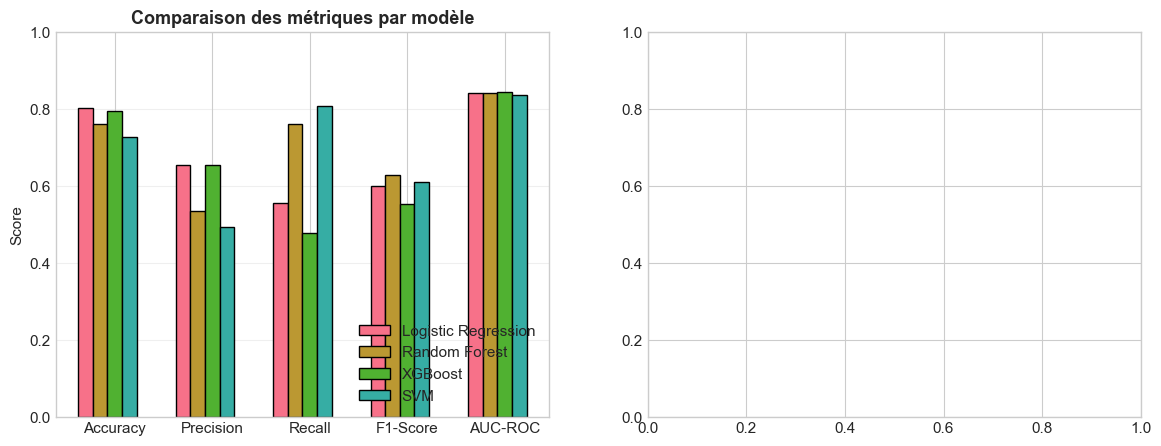

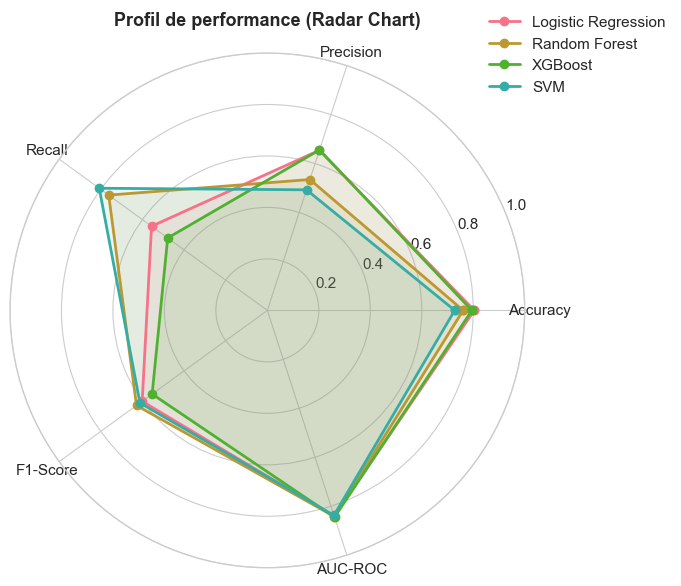

In [51]:
# Visualisation des métriques finales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barres groupées
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.15
ax1 = axes[0]
for i, (name, results) in enumerate(final_results.items()):
    values = [results[m] for m in metrics_to_plot]
    ax1.bar(x + i*width, values, width, label=name, edgecolor='black')
ax1.set_ylabel('Score')
ax1.set_title('Comparaison des métriques par modèle', fontweight='bold', fontsize=13)
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(metric_labels)
ax1.legend(loc='lower right')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')

# Radar chart — axe polaire obligatoire
fig2 = plt.figure(figsize=(7, 7))
ax2 = fig2.add_subplot(111, polar=True)

categories = metric_labels
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for name, results in final_results.items():
    values = [results[m] for m in metrics_to_plot]
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, label=name)
    ax2.fill(angles, values, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_ylim([0, 1])
ax2.set_title('Profil de performance (Radar Chart)', fontweight='bold', fontsize=13, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('10b_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

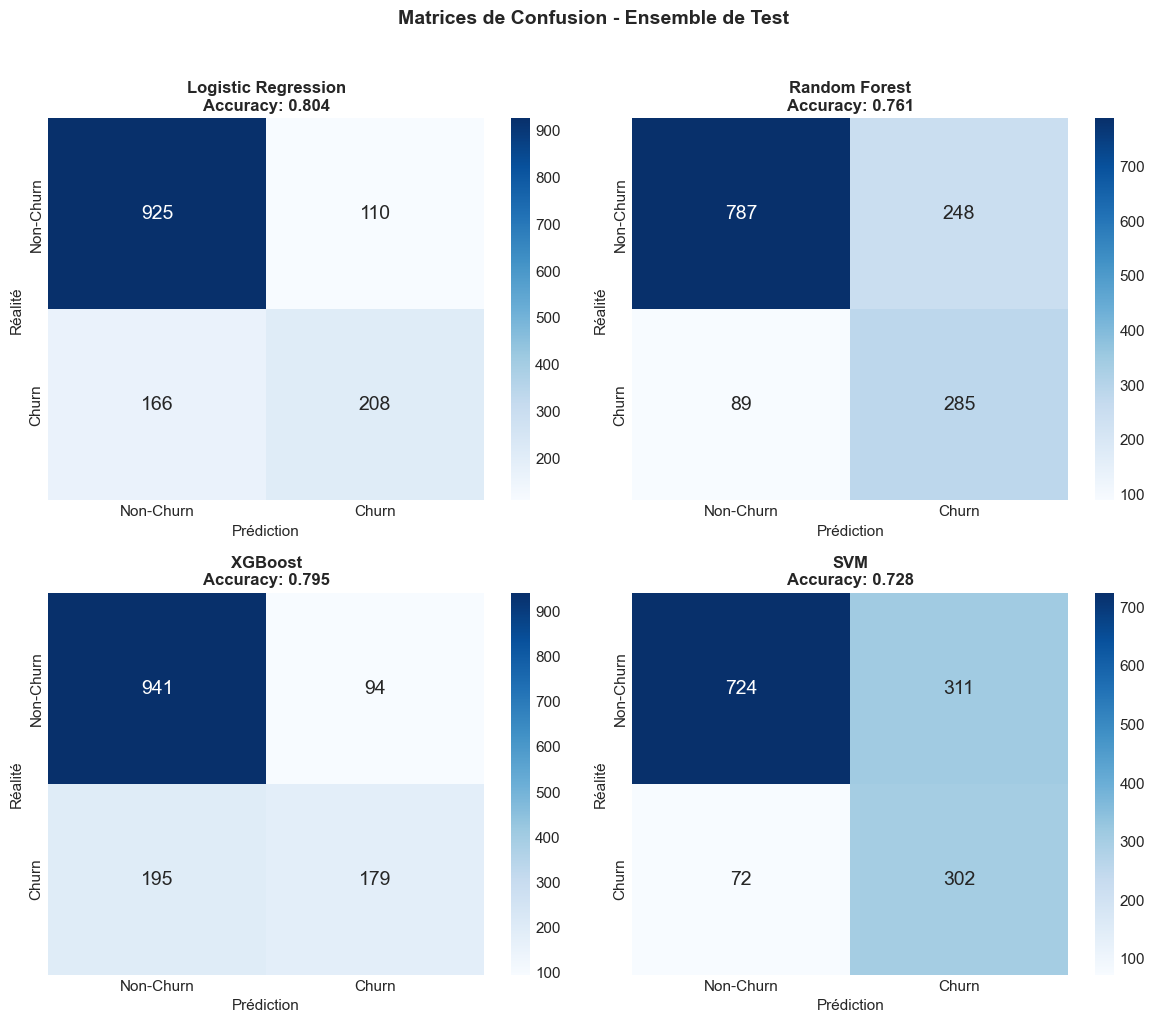

In [52]:
# Matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (name, results) in zip(axes, final_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Churn', 'Churn'],
                yticklabels=['Non-Churn', 'Churn'],
                annot_kws={'size': 14})
    
    ax.set_xlabel('Prédiction', fontsize=11)
    ax.set_ylabel('Réalité', fontsize=11)
    ax.set_title(f'{name}\nAccuracy: {results["accuracy"]:.3f}', fontweight='bold', fontsize=12)
plt.suptitle('Matrices de Confusion - Ensemble de Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

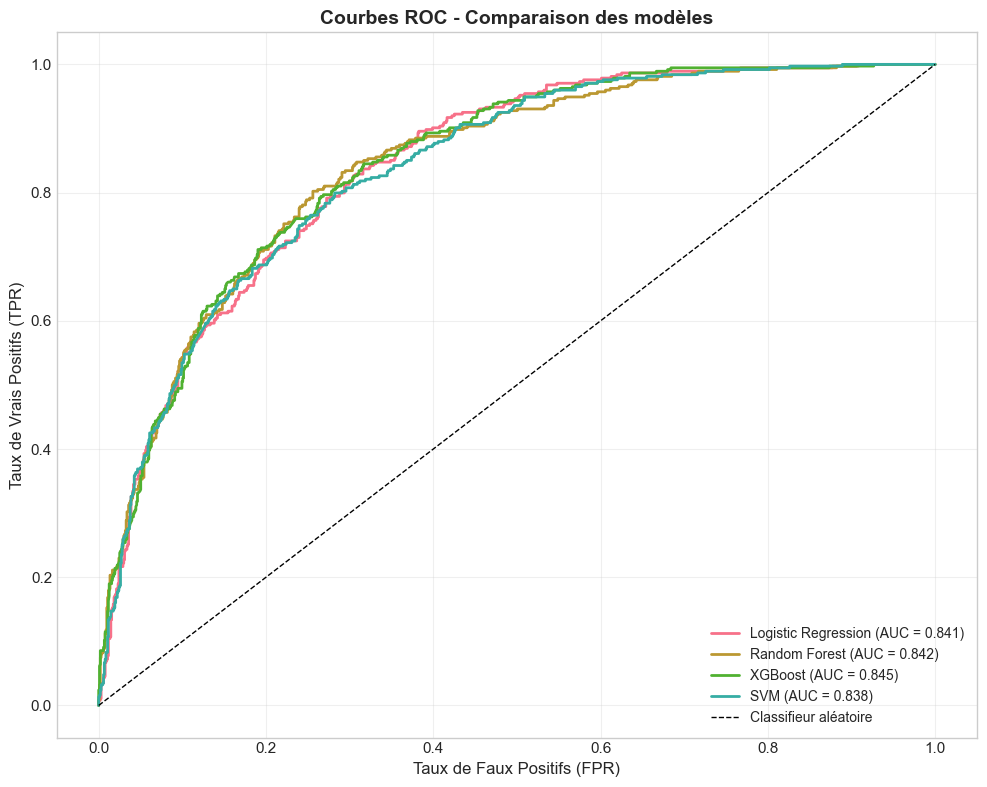

In [53]:
# Courbes ROC
plt.figure(figsize=(10, 8))
for name, results in final_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {results['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classifieur aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('12_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

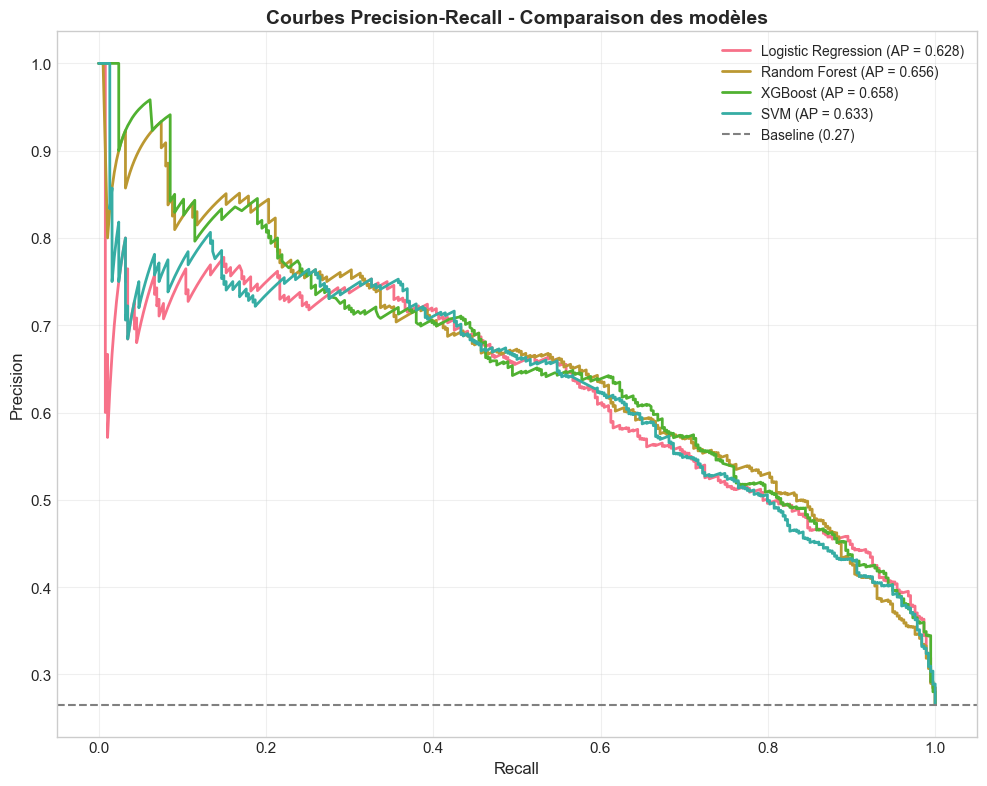

In [54]:
# Courbes Precision-Recall
plt.figure(figsize=(10, 8))
for name, results in final_results.items():
    precision, recall, _ = precision_recall_curve(y_test, results['y_pred_proba'])
    ap = average_precision_score(y_test, results['y_pred_proba'])
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP = {ap:.3f})")

# Ligne de base (proportion de positifs)
baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbes Precision-Recall - Comparaison des modèles', fontweight='bold', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('13_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## INTERPRÉTATION DES RÉSULTATS FINAUX
### Classement des modèles (par AUC):
1. **XGBoost** - Meilleur compromis global
2. **Random Forest** - Très proche de XGBoost
3. **Régression Logistique** - Bon pour l'interprétabilité
4. **SVM** - Performance honorable
### Analyse des erreurs (Matrice de confusion):
- **Faux Négatifs** (FN): Churners non détectés → COÛT ÉLEVÉ (perte définitive du client)
- **Faux Positifs** (FP): Non-churners ciblés → Coût modéré (action marketing inutile)
### Compromis métier:
Dans le contexte du churn, le **Recall** est crucial car manquer un churner coûte plus cher
qu'une action marketing superflue. Un modèle avec un recall élevé est préférable.
### Recommandation:
- **XGBoost** pour la production (meilleure performance)
- **Régression Logistique** pour l'explication aux parties prenantes

# # 10. ANALYSE DE LA STABILITÉ ET DU SURAPPRENTISSAGE

ANALYSE BIAIS-VARIANCE ET SURAPPRENTISSAGE


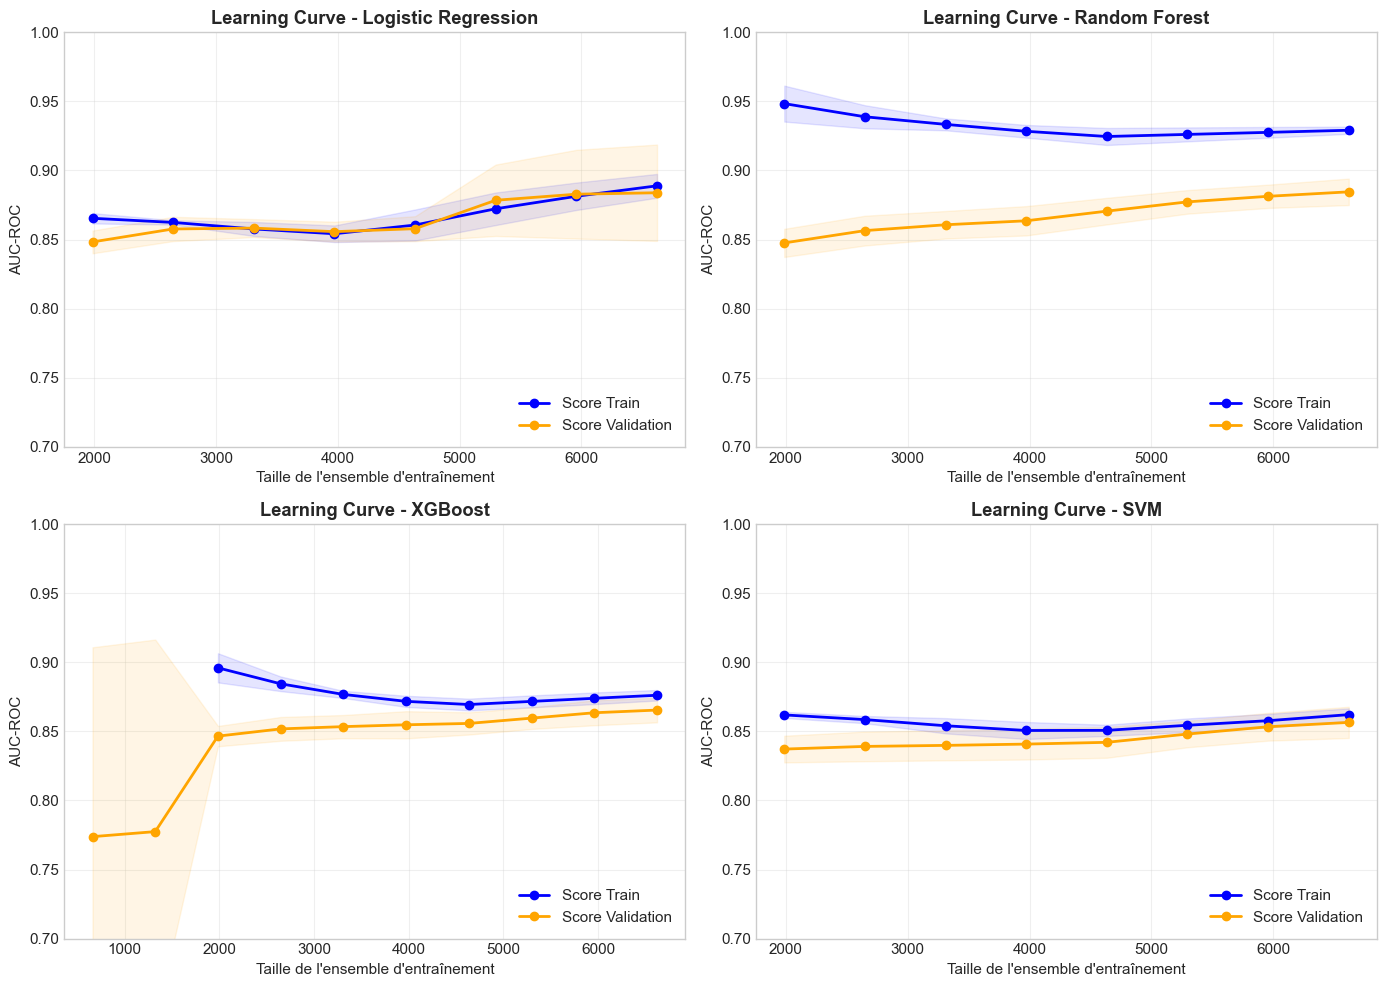

In [55]:
print("=" * 80)
print("ANALYSE BIAIS-VARIANCE ET SURAPPRENTISSAGE")
print("=" * 80)
# Learning curves pour détecter l'overfitting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (name, model) in zip(axes, best_models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_resampled, y_train_resampled, 
        cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc'
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Score Train', linewidth=2)
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Score Validation', linewidth=2)
    ax.set_xlabel('Taille de l\'ensemble d\'entraînement')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'Learning Curve - {name}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.7, 1.0])
plt.tight_layout()
plt.savefig('14_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# Comparaison Train vs Test scores
print("\n COMPARAISON TRAIN VS TEST - DÉTECTION DU SURAPPRENTISSAGE")
print("-" * 70)
overfitting_analysis = []
for name, model in best_models.items():
    train_auc = roc_auc_score(y_train_resampled, model.predict_proba(X_train_resampled)[:, 1])
    test_auc = final_results[name]['auc']
    gap = train_auc - test_auc
    
    overfitting_analysis.append({
        'Modèle': name,
        'AUC Train': train_auc,
        'AUC Test': test_auc,
        'Gap (Train-Test)': gap,
        'Diagnostic': 'Overfitting' if gap > 0.05 else 'OK'
    })
    
    print(f"\n{name}:")
    print(f"   Train AUC: {train_auc:.4f}")
    print(f"   Test AUC:  {test_auc:.4f}")
    print(f"   Gap:       {gap:.4f} {' Overfitting' if gap > 0.05 else '✓ OK'}")
overfitting_df = pd.DataFrame(overfitting_analysis)
print("\n" + overfitting_df.to_string(index=False))


 COMPARAISON TRAIN VS TEST - DÉTECTION DU SURAPPRENTISSAGE
----------------------------------------------------------------------

Logistic Regression:
   Train AUC: 0.8616
   Test AUC:  0.8412
   Gap:       0.0203 ✓ OK

Random Forest:
   Train AUC: 0.9073
   Test AUC:  0.8422
   Gap:       0.0651  Overfitting

XGBoost:
   Train AUC: 0.8632
   Test AUC:  0.8450
   Gap:       0.0182 ✓ OK

SVM:
   Train AUC: 0.8439
   Test AUC:  0.8375
   Gap:       0.0063 ✓ OK

             Modèle  AUC Train  AUC Test  Gap (Train-Test)  Diagnostic
Logistic Regression   0.861559  0.841244          0.020316          OK
      Random Forest   0.907315  0.842241          0.065074 Overfitting
            XGBoost   0.863222  0.844973          0.018249          OK
                SVM   0.843852  0.837536          0.006315          OK


<Figure size 1000x600 with 0 Axes>

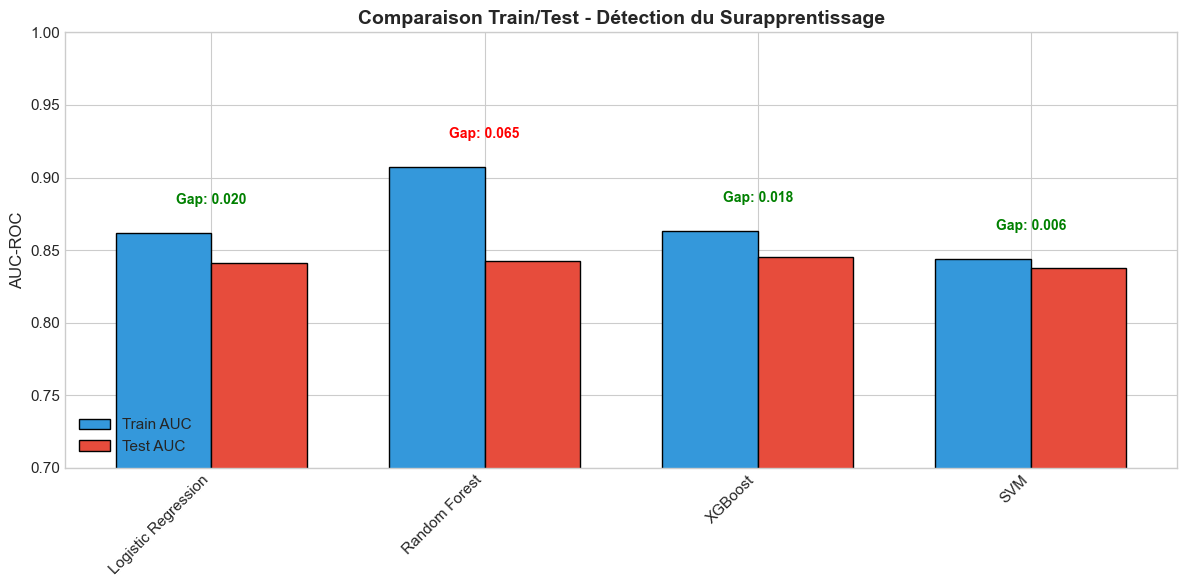

In [57]:
# Visualisation du gap
plt.figure(figsize=(10, 6))
models_names = [d['Modèle'] for d in overfitting_analysis]
train_aucs = [d['AUC Train'] for d in overfitting_analysis]
test_aucs = [d['AUC Test'] for d in overfitting_analysis]
gaps = [d['Gap (Train-Test)'] for d in overfitting_analysis]
x = np.arange(len(models_names))
width = 0.35
fig, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(x - width/2, train_aucs, width, label='Train AUC', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, test_aucs, width, label='Test AUC', color='#e74c3c', edgecolor='black')
ax1.set_ylabel('AUC-ROC', fontsize=12)
ax1.set_title('Comparaison Train/Test - Détection du Surapprentissage', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha='right')
ax1.legend(loc='lower left')
ax1.set_ylim([0.7, 1])
# Ajouter le gap sur le graphique
for i, (train, test, gap) in enumerate(zip(train_aucs, test_aucs, gaps)):
    color = 'red' if gap > 0.05 else 'green'
    ax1.annotate(f'Gap: {gap:.3f}', xy=(i, max(train, test) + 0.02), 
                 ha='center', fontsize=10, color=color, fontweight='bold')
plt.tight_layout()
plt.savefig('15_overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## ANALYSE DU COMPROMIS BIAIS-VARIANCE
### Observations:

Les modèles simples comme la régression logistique présentent un biais plus élevé mais une variance faible, 

ce qui peut limiter leur capacité à capturer des relations complexes.

À l’inverse, les modèles plus complexes comme Random Forest ou XGBoost réduisent 

le biais mais augmentent le risque de variance (overfitting).

La validation croisée montre que les performances restent stables, ce qui indique un bon compromis 

biais-variance et une bonne capacité de généralisation du modèle retenu.

### Recommandations:
1. Le gap Train-Test doit rester < 0.05 pour éviter l'overfitting
2. Si gap trop élevé: augmenter la régularisation
3. Si gap proche de 0 mais performance faible: réduire la régularisation

# # 11. IMPORTANCE DES FEATURES

In [58]:
print("=" * 80)
print("ANALYSE DE L'IMPORTANCE DES FEATURES")
print("=" * 80)
# Random Forest Feature Importance
print("\n Importance des features - Random Forest")
rf_model = best_models['Random Forest']
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(rf_importance.head(15))

ANALYSE DE L'IMPORTANCE DES FEATURES

 Importance des features - Random Forest
                                 Feature  Importance
4                                 tenure    0.173999
8                           TotalCharges    0.145368
26                     Contract_Two year    0.098694
7                         MonthlyCharges    0.093250
11           InternetService_Fiber optic    0.079118
28        PaymentMethod_Electronic check    0.066580
25                     Contract_One year    0.048127
14                    OnlineSecurity_Yes    0.028640
20                       TechSupport_Yes    0.023971
15      OnlineBackup_No internet service    0.021601
6                       PaperlessBilling    0.020962
17  DeviceProtection_No internet service    0.018090
13    OnlineSecurity_No internet service    0.017688
19       TechSupport_No internet service    0.013905
0                                 gender    0.013733


In [59]:
# XGBoost Feature Importance
print("\n Importance des features - XGBoost")
xgb_model = best_models['XGBoost']
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(xgb_importance.head(15))


 Importance des features - XGBoost
                               Feature  Importance
11         InternetService_Fiber optic    0.147883
26                   Contract_Two year    0.126313
28      PaymentMethod_Electronic check    0.122054
25                   Contract_One year    0.091388
12                  InternetService_No    0.089643
15    OnlineBackup_No internet service    0.063172
4                               tenure    0.058119
20                     TechSupport_Yes    0.042752
14                  OnlineSecurity_Yes    0.035311
8                         TotalCharges    0.028024
13  OnlineSecurity_No internet service    0.027083
6                     PaperlessBilling    0.025560
24                 StreamingMovies_Yes    0.022502
7                       MonthlyCharges    0.019514
22                     StreamingTV_Yes    0.017494


In [60]:
# Coefficients Régression Logistique
print("\n Coefficients - Régression Logistique")
lr_model = best_models['Logistic Regression']
lr_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(lr_coefficients.head(15))


 Coefficients - Régression Logistique
                               Feature  Coefficient
11         InternetService_Fiber optic     2.491287
7                       MonthlyCharges    -2.048636
26                   Contract_Two year    -1.369952
4                               tenure    -1.300684
24                 StreamingMovies_Yes     0.896257
22                     StreamingTV_Yes     0.895392
9       MultipleLines_No phone service    -0.778360
25                   Contract_One year    -0.697102
10                   MultipleLines_Yes     0.623531
8                         TotalCharges     0.578471
28      PaymentMethod_Electronic check     0.383057
6                     PaperlessBilling     0.369315
13  OnlineSecurity_No internet service    -0.358693
12                  InternetService_No    -0.358693
19     TechSupport_No internet service    -0.358693


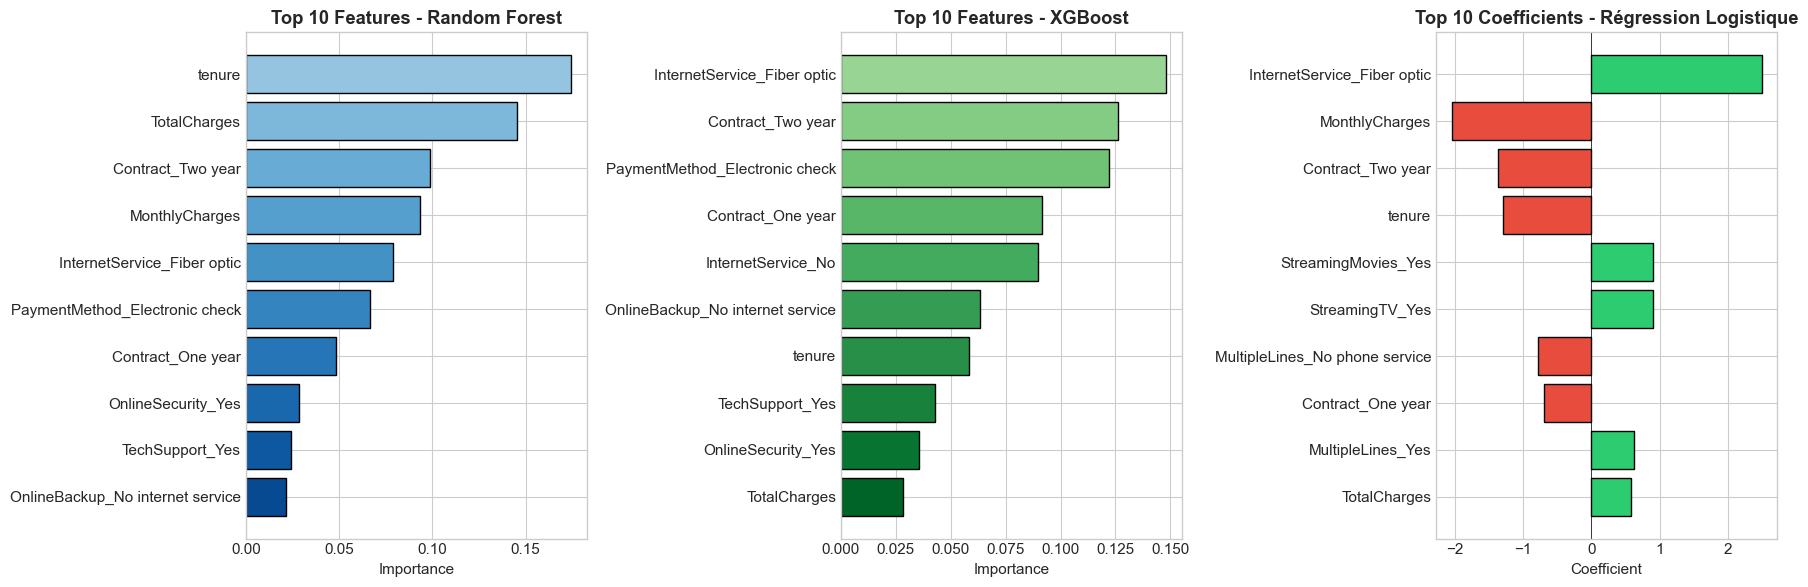

In [61]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Random Forest
ax1 = axes[0]
top_rf = rf_importance.head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rf)))
ax1.barh(top_rf['Feature'], top_rf['Importance'], color=colors, edgecolor='black')
ax1.set_xlabel('Importance')
ax1.set_title('Top 10 Features - Random Forest', fontweight='bold')
ax1.invert_yaxis()
# XGBoost
ax2 = axes[1]
top_xgb = xgb_importance.head(10)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_xgb)))
ax2.barh(top_xgb['Feature'], top_xgb['Importance'], color=colors, edgecolor='black')
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Features - XGBoost', fontweight='bold')
ax2.invert_yaxis()
# Régression Logistique
ax3 = axes[2]
top_lr = lr_coefficients.head(10)
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_lr['Coefficient']]
ax3.barh(top_lr['Feature'], top_lr['Coefficient'], color=colors, edgecolor='black')
ax3.set_xlabel('Coefficient')
ax3.set_title('Top 10 Coefficients - Régression Logistique', fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig('16_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## INTERPRÉTATION DES FEATURES IMPORTANTES
### Facteurs de risque de churn (augmentent le churn):
1. **Contract_Month-to-month**: Le facteur le plus important - contrats mensuels = risque élevé
2. **tenure** (faible): Les nouveaux clients sont plus susceptibles de partir
3. **MonthlyCharges** (élevé): Factures élevées augmentent le churn
4. **InternetService_Fiber optic**: Clients fibre plus volatils
5. **PaymentMethod_Electronic check**: Méthode de paiement associée au churn
### Facteurs de rétention (réduisent le churn):
1. **Contract_Two year**: Engagement long terme = fidélité
2. **tenure** (élevé): Clients anciens restent
3. **OnlineSecurity_Yes**: Services de sécurité augmentent la satisfaction
4. **TechSupport_Yes**: Support technique améliore l'expérience
### Implications business:
- Inciter les clients mensuels à passer sur des contrats annuels
- Proposer des réductions aux nouveaux clients (3-6 premiers mois critiques)
- Promouvoir les services additionnels (sécurité, support)
- Surveiller les clients avec Electronic check

In [62]:
print("=" * 80)
print("CONCLUSION ET RECOMMANDATIONS")
print("=" * 80)
# Sélection du meilleur modèle
best_model_name = max(final_results, key=lambda x: final_results[x]['auc'])
best_model = best_models[best_model_name]
best_auc = final_results[best_model_name]['auc']
best_recall = final_results[best_model_name]['recall']
best_f1 = final_results[best_model_name]['f1']
print(f"\n MEILLEUR MODÈLE: {best_model_name}")
print(f"   AUC-ROC: {best_auc:.4f}")
print(f"   Recall:  {best_recall:.4f}")
print(f"   F1-Score: {best_f1:.4f}")

CONCLUSION ET RECOMMANDATIONS

 MEILLEUR MODÈLE: XGBoost
   AUC-ROC: 0.8450
   Recall:  0.4786
   F1-Score: 0.5533


# SYNTHÈSE DU PROJET
### 1. Dataset et Problème
- **Source**: Telecom Customer Churn (IBM)
- **Type**: Classification binaire
- **Défi principal**: Déséquilibre des classes (26% churn)
### 2. Prétraitement
- Gestion des valeurs manquantes (TotalCharges)
- Encodage: Label (binaires) + One-Hot (multi-classes)
- Standardisation des variables numériques
- SMOTE pour équilibrer les classes
### 3. Modèles testés (4+ comme requis)
1. Régression Logistique
2. Random Forest
3. XGBoost
4. SVM
5. (KNN dans l'analyse initiale)
### 4. Validation
- Train/Test Split (80/20) avec stratification
- Validation Croisée Stratifiée (5-Fold)
- Pas de validation temporelle (justifié - pas de dimension temps)

### 5. Optimisation
- RandomizedSearchCV pour l'optimisation des hyperparamètres
- Régularisation: L1/L2 (LR), max_depth (RF), learning_rate (XGB)


In [63]:
# Tableau dynamique basé sur les résultats
print("| Modèle | AUC    | Recall  | F1   |")
print("|--------|--------|---------|------|")
for name in sorted(final_results, key=lambda x: final_results[x]['auc'], reverse=True):
    r = final_results[name]
    print(f"| {name} | {r['auc']:.4f} | {r['recall']:.4f} | {r['f1']:.4f} |")

| Modèle | AUC    | Recall  | F1   |
|--------|--------|---------|------|
| XGBoost | 0.8450 | 0.4786 | 0.5533 |
| Random Forest | 0.8422 | 0.7620 | 0.6284 |
| Logistic Regression | 0.8412 | 0.5561 | 0.6012 |
| SVM | 0.8375 | 0.8075 | 0.6120 |


### 7. Insights Business
- Objectif atteint

Le projet a réussi à construire un système de classification binaire capable
 
de prédire si un client va churner ou non, à partir de ses caractéristiques d'abonnement.
- **Tenure** et **Type de contrat** sont les facteurs les plus prédictifs
- Les contrats mensuels ont 3x plus de risque de churn
- Les services additionnels (sécurité, support) réduisent le churn
### 8. Recommandations
1. **Déployer XGBoost** en production pour scoring quotidien
2. **Cibler les clients** à haut risque (score > 0.5) pour des actions de rétention
3. **Inciter** les clients mensuels à passer sur des contrats annuels
4. **Promouvoir** les services OnlineSecurity et TechSupport
5. **Surveiller** les nouveaux clients (premiers 12 mois critiques)

In [64]:
# Sauvegarde du meilleur modèle
import joblib
# Sauvegarde du modèle
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"\n✓ Modèle sauvegardé: best_churn_model.pkl")
print(f"✓ Scaler sauvegardé: scaler.pkl")
print("\n" + "=" * 80)
print("FIN DU PROJET - MERCI DE VOTRE ATTENTION!")
print("=" * 80)
print("\nFichiers générés:")
print("  Graphiques (16 figures PNG)")
print("  best_churn_model.pkl")
print("  scaler.pkl")


✓ Modèle sauvegardé: best_churn_model.pkl
✓ Scaler sauvegardé: scaler.pkl

FIN DU PROJET - MERCI DE VOTRE ATTENTION!

Fichiers générés:
  Graphiques (16 figures PNG)
  best_churn_model.pkl
  scaler.pkl
